# 📊 Nexus V3 — Complete Research Visualization Suite

**15 publication-quality figures** from the Gravity Algorithm research.

| # | Figure | Description |
|---|--------|-------------|
| 1 | Error Probability Overlay | All 6 graphs, P_src vs k |
| 2 | Error Probability Subplots | Individual per-graph curves |
| 3 | NE Phase Transition | Error avalanche at k=17 |
| 4 | Boundary Sweep | Safe/Fail bw across graphs |
| 5 | Conjecture Scorecard | All 4 conjectures vs actual |
| 6 | Collision vs Error | Same-bucket ≠ error |
| 7 | Family 1 Ratio | safe_bw/W is NOT constant |
| 8 | Family 3 Non-Monotonic | Errors appear/disappear |
| 9 | Family 5 Gap | Gap vs safe_bw staircase |
| 10 | V27 Performance | V18 vs V27 speedup |
| 11 | Version Evolution | 27-version journey |
| 12 | Two Regimes | Steep sigmoid vs gradual |
| 13 | Convergent Path Diagram | Error mechanism visual |
| 14 | Error Heatmap | P_src across graphs and k |
| 15 | Research Timeline | 12 phases, 27 versions |

**Save instructions**: Right-click each figure → *Save image as...* → use the filename shown in the heading above each plot.

In [1]:
# Install dependencies (run once)
!pip install matplotlib numpy -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.patches import Patch, Rectangle, Circle

# ─── Style configuration ───
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.pad_inches': 0.2,
})

# Color palette — distinct, colorblind-friendly
COLORS = {
    'BAY': '#2196F3',   # Blue
    'COL': '#4CAF50',   # Green
    'FLA': '#FF9800',   # Orange
    'NW':  '#9C27B0',   # Purple
    'NE':  '#F44336',   # Red
    'USA': '#795548',   # Brown
}

MARKERS = {
    'BAY': 'o',
    'COL': 's',
    'FLA': '^',
    'NW':  'D',
    'NE':  'v',
    'USA': 'P',
}

print('✅ Setup complete')

✅ Setup complete


In [3]:
# ═══════════════════════════════════════════════════════════════════
#  ALL DATA — hardcoded from experimental results
# ═══════════════════════════════════════════════════════════════════

# ─── Error Probability (from errprob_results.txt) ───

# BAY: w_min=2, 100 sources, k=1..60
BAY_k = list(range(1, 61))
BAY_psrc = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0.05,0.09,0.15,0.15,0.21,0.22,0.29,0.34,0.37,0.35,0.53,0.48,
    0.59,0.51,0.66,0.59,0.54,0.64,0.60,0.59,0.67,0.75,0.69,0.73,
    0.66,0.74,0.69,0.74,0.80,0.72,0.78,0.79,0.83,0.81,0.83,0.87
]
BAY_maxerr = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    34,34,34,34,34,67,89,67,67,109,67,109,109,109,67,109,
    67,89,67,67,89,89,67,142,67,122,67,142,142,122,142,67,122,67,142,109
]
BAY_totalerr = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    138,231,446,434,646,701,945,1013,1201,1210,1858,1607,
    2084,1909,2176,2138,1861,2394,2135,2027,2856,2883,2486,2818,
    2504,2765,3054,3124,3229,3208,3372,3108,3444,3247,3656,3457
]

# COL: w_min=2, 100 sources, k=1..60
COL_k = list(range(1, 61))
COL_psrc = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0.01,0.01,0.02,0.01,0.02,0.03,0.03,0.02,0.07,0.07,0.07,0.04,0.08,0.03,
    0.04,0.13,0.12,0.11,0.09,0.12,0.12,0.12,0.12,0.10,0.16,0.12
]
COL_maxerr = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,2,2,2
]

# FLA: w_min=1, 50 sources, k=1..50
FLA_k = list(range(1, 51))
FLA_psrc = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0.12,0.04,0.08,0.04,0.12,0.12,0.16,0.16,0.16,0.22,0.32,0.16,
    0.30,0.20,0.28,0.38,0.46,0.48,0.50,0.48,0.46,0.44,0.58,0.62,0.62,0.78
]
FLA_maxerr = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    2,2,2,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,4,4,5,5,4,6,18
]

# NW: w_min=2, 50 sources, k=1..50
NW_k = list(range(1, 51))
NW_psrc = [
    0,0,0,0,0,0,0,0,0,0,0,
    0.02,0,0,0.04,0.06,0.08,0.08,0.08,0.08,0.06,0.16,0.14,0.12,
    0.16,0.12,0.24,0.12,0.22,0.14,0.22,0.26,0.24,0.34,0.32,0.34,
    0.34,0.32,0.52,0.44,0.34,0.54,0.50,0.50,0.48,0.44,0.58,0.54,0.62,0.54
]

# NE: w_min=2, 50 sources, k=1..50
NE_k = list(range(1, 51))
NE_psrc = [
    0,0,0,0,
    0.18,0.34,0.36,0.50,0.62,0.58,0.72,0.70,0.64,0.78,0.66,0.82,0.80,
    0.88,0.82,0.86,0.84,0.92,0.90,0.94,1.00,0.94,0.98,0.96,1.00,1.00,
    1.00,1.00,1.00,1.00,0.98,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,
    1.00,1.00,1.00,1.00,1.00,1.00,1.00
]
NE_maxerr = [
    0,0,0,0,
    1,1,1,1,1,1,1,1,1,1,1,2,2270,2270,2277,2270,3140,2315,2390,2397,
    2909,3140,3186,7726,7405,7405,5738,7739,7689,7852,7868,7803,7407,
    7898,7569,8230,7851,7694,7978,88129,9273,9216,83152,86625,89785,86287
]
NE_totalerr = [
    0,0,0,0,
    9,17,18,25,31,29,36,35,32,39,33,43,2310,13449,7262,13477,28079,
    32140,18598,39598,27067,40024,43869,76308,65586,56187,62322,62639,
    98021,92013,120806,122110,118400,150832,118820,157713,136322,141973,
    132708,269773,152266,176170,236617,242244,341077,333462
]

# USA: w_min=1, 20 sources, k=1..30
USA_k = list(range(1, 31))
USA_psrc = [
    0,0,0,0,0,0,0,0,
    0.25,0.20,0.20,0.45,0.60,0.70,0.70,0.70,0.75,0.90,0.95,0.85,
    0.95,1.00,1.00,0.95,1.00,1.00,1.00,1.00,1.00,1.00
]
USA_maxerr = [
    0,0,0,0,0,0,0,0,
    1,1,1,31,35,44,35,36,43,33,44,45,45,50,56,56,40,49,68,68,86,56
]

# ─── Boundary Sweep (from bwsweepall_results.txt) ───
boundary_data = {
    'BAY': (321270, 800172, 2, 48, 50, 24, 25),
    'COL': (435666, 1057066, 2, 52, 54, 26, 27),
    'FLA': (1070376, 2712798, 2, 54, 56, 27, 28),
    'NW':  (1207945, 2840208, 2, 26, 28, 13, 14),
    'NE':  (1524453, 3897636, 2, 8, 10, 4, 5),
    'USA': (23947347, 58333344, 1, 8, 9, 8, 9),
}

# ─── Conjecture Scorecard (from boundhunt_results.txt) ───
conjecture_data = {
    'BAY': (48, 2, 2, 1),
    'COL': (52, 2, 2, 1),
    'FLA': (54, 1, 1, 1),
    'NW':  (26, 2, 2, 1),
    'NE':  (8, 2, 2, 1),
    'USA': (8, 1, 1, 1),
}

# ─── Collision vs Error (from boundverify_results.txt) ───
collision_data = {
    'BAY': (5353, 126, 5483, 194),
    'NE':  (1159, 0, 1594, 4),
    'NW':  (2559, 4, 2821, 70),
    'COL': (10815, 0, 11171, 0),
}

# ─── Worst-Case Family 1 (from worstcase_results.txt) ───
family1_W = [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50]
family1_safe = [3,8,8,9,13,18,19,19,19,24,24,31,31,32,32,44,45,45,46,47,47,48,48,49,75]
family1_ratio = [s/w for s, w in zip(family1_safe, family1_W)]

# ─── Worst-Case Family 3: Non-monotonic errors ───
family3_bw = list(range(1, 61))
family3_errors = [
    0,0,0,0,0,0,0,0,13,13,13,13,0,13,10,13,0,13,13,13,10,13,13,13,13,
    0,13,13,13,13,13,13,13,0,10,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,
    4,0,10,13,13,13,13,13,13,13
]

# ─── Worst-Case Family 5: Gap vs safe_bw ───
family5_gap = list(range(1, 51))
family5_safe = [
    17,17,17,17,17,21,21,21,21,21,21,26,26,26,33,34,34,34,34,35,35,35,35,
    48,48,48,48,49,49,50,50,50,51,51,51,52,52,52,53,53,53,54,54,54,82,83,83,84,84,85
]

# ─── V27 Performance (from PROGRESS.md) ───
v27_perf = {
    'BAY': (1.80, 1.47, True, True),
    'CA':  (14.84, 10.66, True, True),
    'TX':  (10.63, 7.46, True, True),
    'USA': (2.03, 1.61, False, True),
}

print(f'✅ All data loaded')
print(f'   BAY: {len(BAY_k)} k-values, COL: {len(COL_k)}, FLA: {len(FLA_k)}')
print(f'   NW: {len(NW_k)}, NE: {len(NE_k)}, USA: {len(USA_k)}')

✅ All data loaded
   BAY: 60 k-values, COL: 60, FLA: 50
   NW: 50, NE: 50, USA: 30


---
## Figure 1 — `fig01_error_probability_overlay.png`
**The central result.** P(source has ≥1 error) vs k for all 6 DIMACS graphs overlaid.

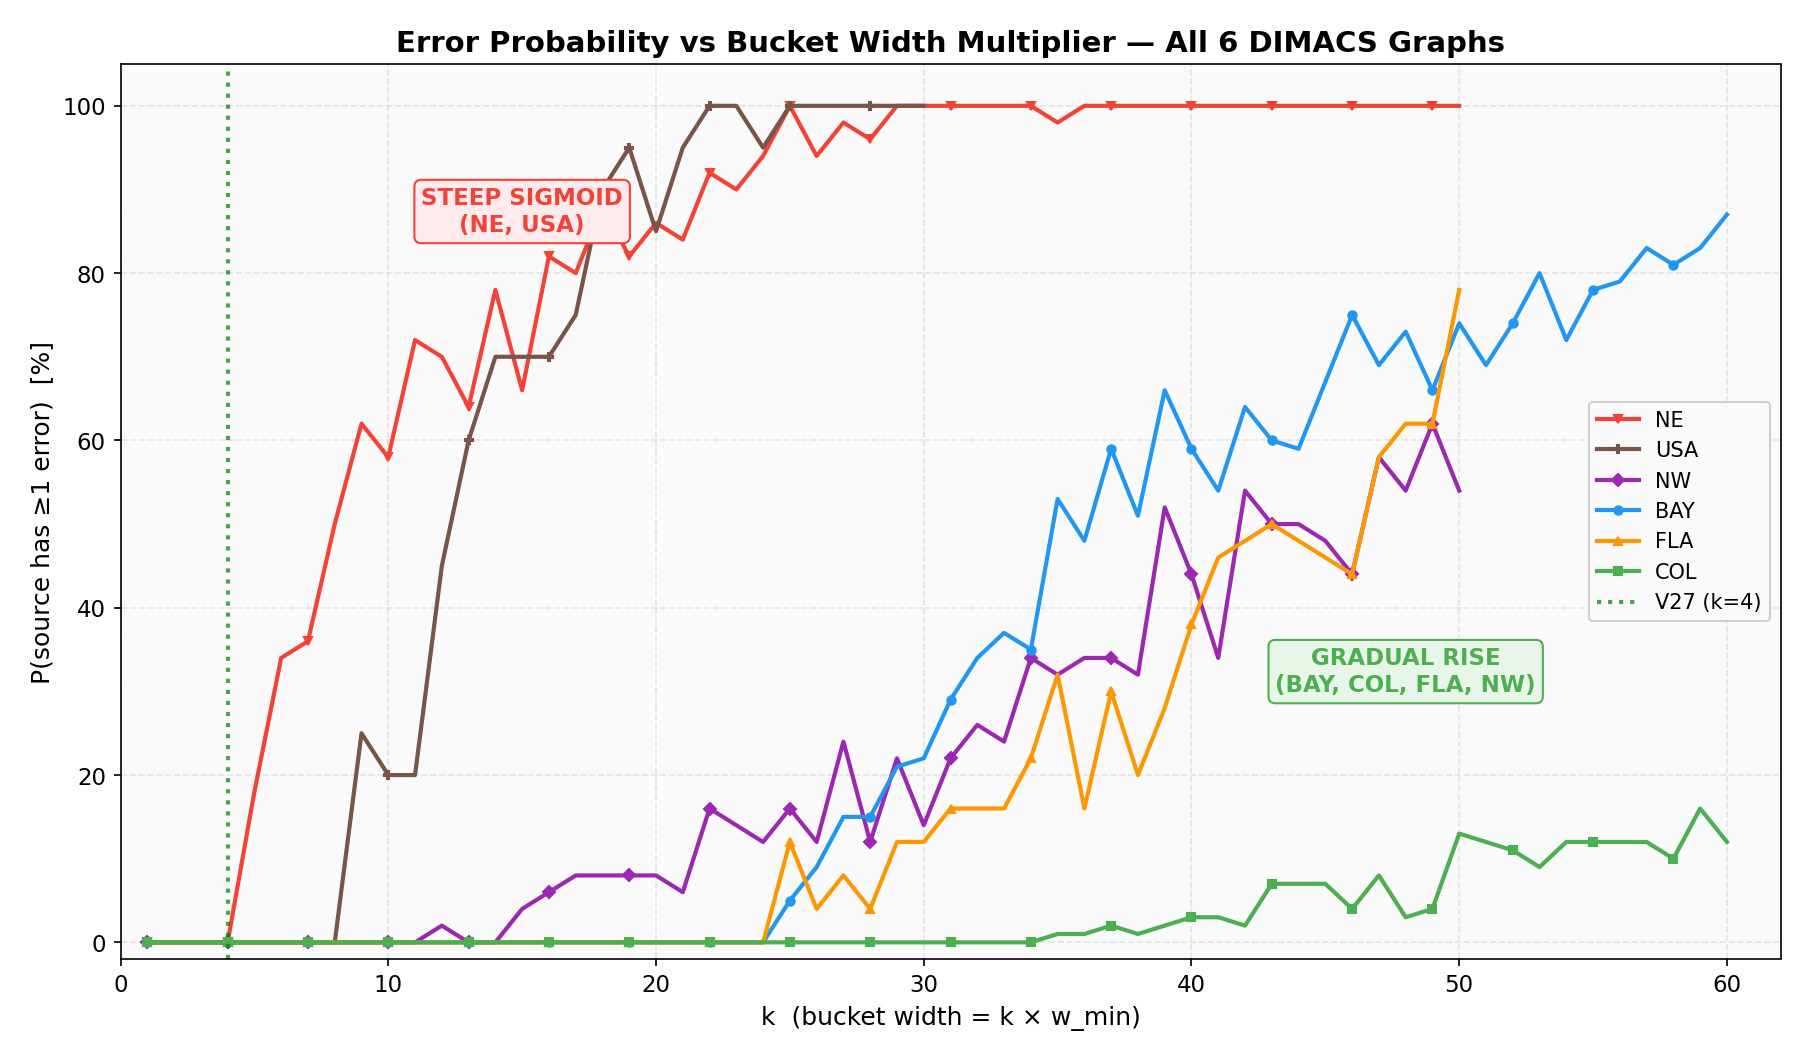

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

datasets = [
    ('NE', NE_k, NE_psrc),
    ('USA', USA_k, USA_psrc),
    ('NW', NW_k, NW_psrc),
    ('BAY', BAY_k, BAY_psrc),
    ('FLA', FLA_k, FLA_psrc),
    ('COL', COL_k, COL_psrc),
]

for name, k, psrc in datasets:
    ax.plot(k, [p * 100 for p in psrc],
            color=COLORS[name], marker=MARKERS[name],
            markersize=4, linewidth=2, label=name, markevery=3)

ax.axvline(x=4, color='green', linestyle=':', linewidth=2, alpha=0.7, label='V27 (k=4)')

ax.set_xlabel('k  (bucket width = k × w_min)')
ax.set_ylabel('P(source has ≥1 error)  [%]')
ax.set_title('Error Probability vs Bucket Width Multiplier — All 6 DIMACS Graphs')
ax.set_xlim(0, 62)
ax.set_ylim(-2, 105)
ax.legend(loc='center right', framealpha=0.9)

ax.annotate('STEEP SIGMOID\n(NE, USA)', xy=(15, 85), fontsize=11,
            color='#F44336', fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#F44336'))
ax.annotate('GRADUAL RISE\n(BAY, COL, FLA, NW)', xy=(48, 30), fontsize=11,
            color='#4CAF50', fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#4CAF50'))

plt.tight_layout()
plt.show()

---
## Figure 2 — `fig02_error_probability_subplots.png`
Individual panels for each graph with fill-under-curve and first-error annotation.

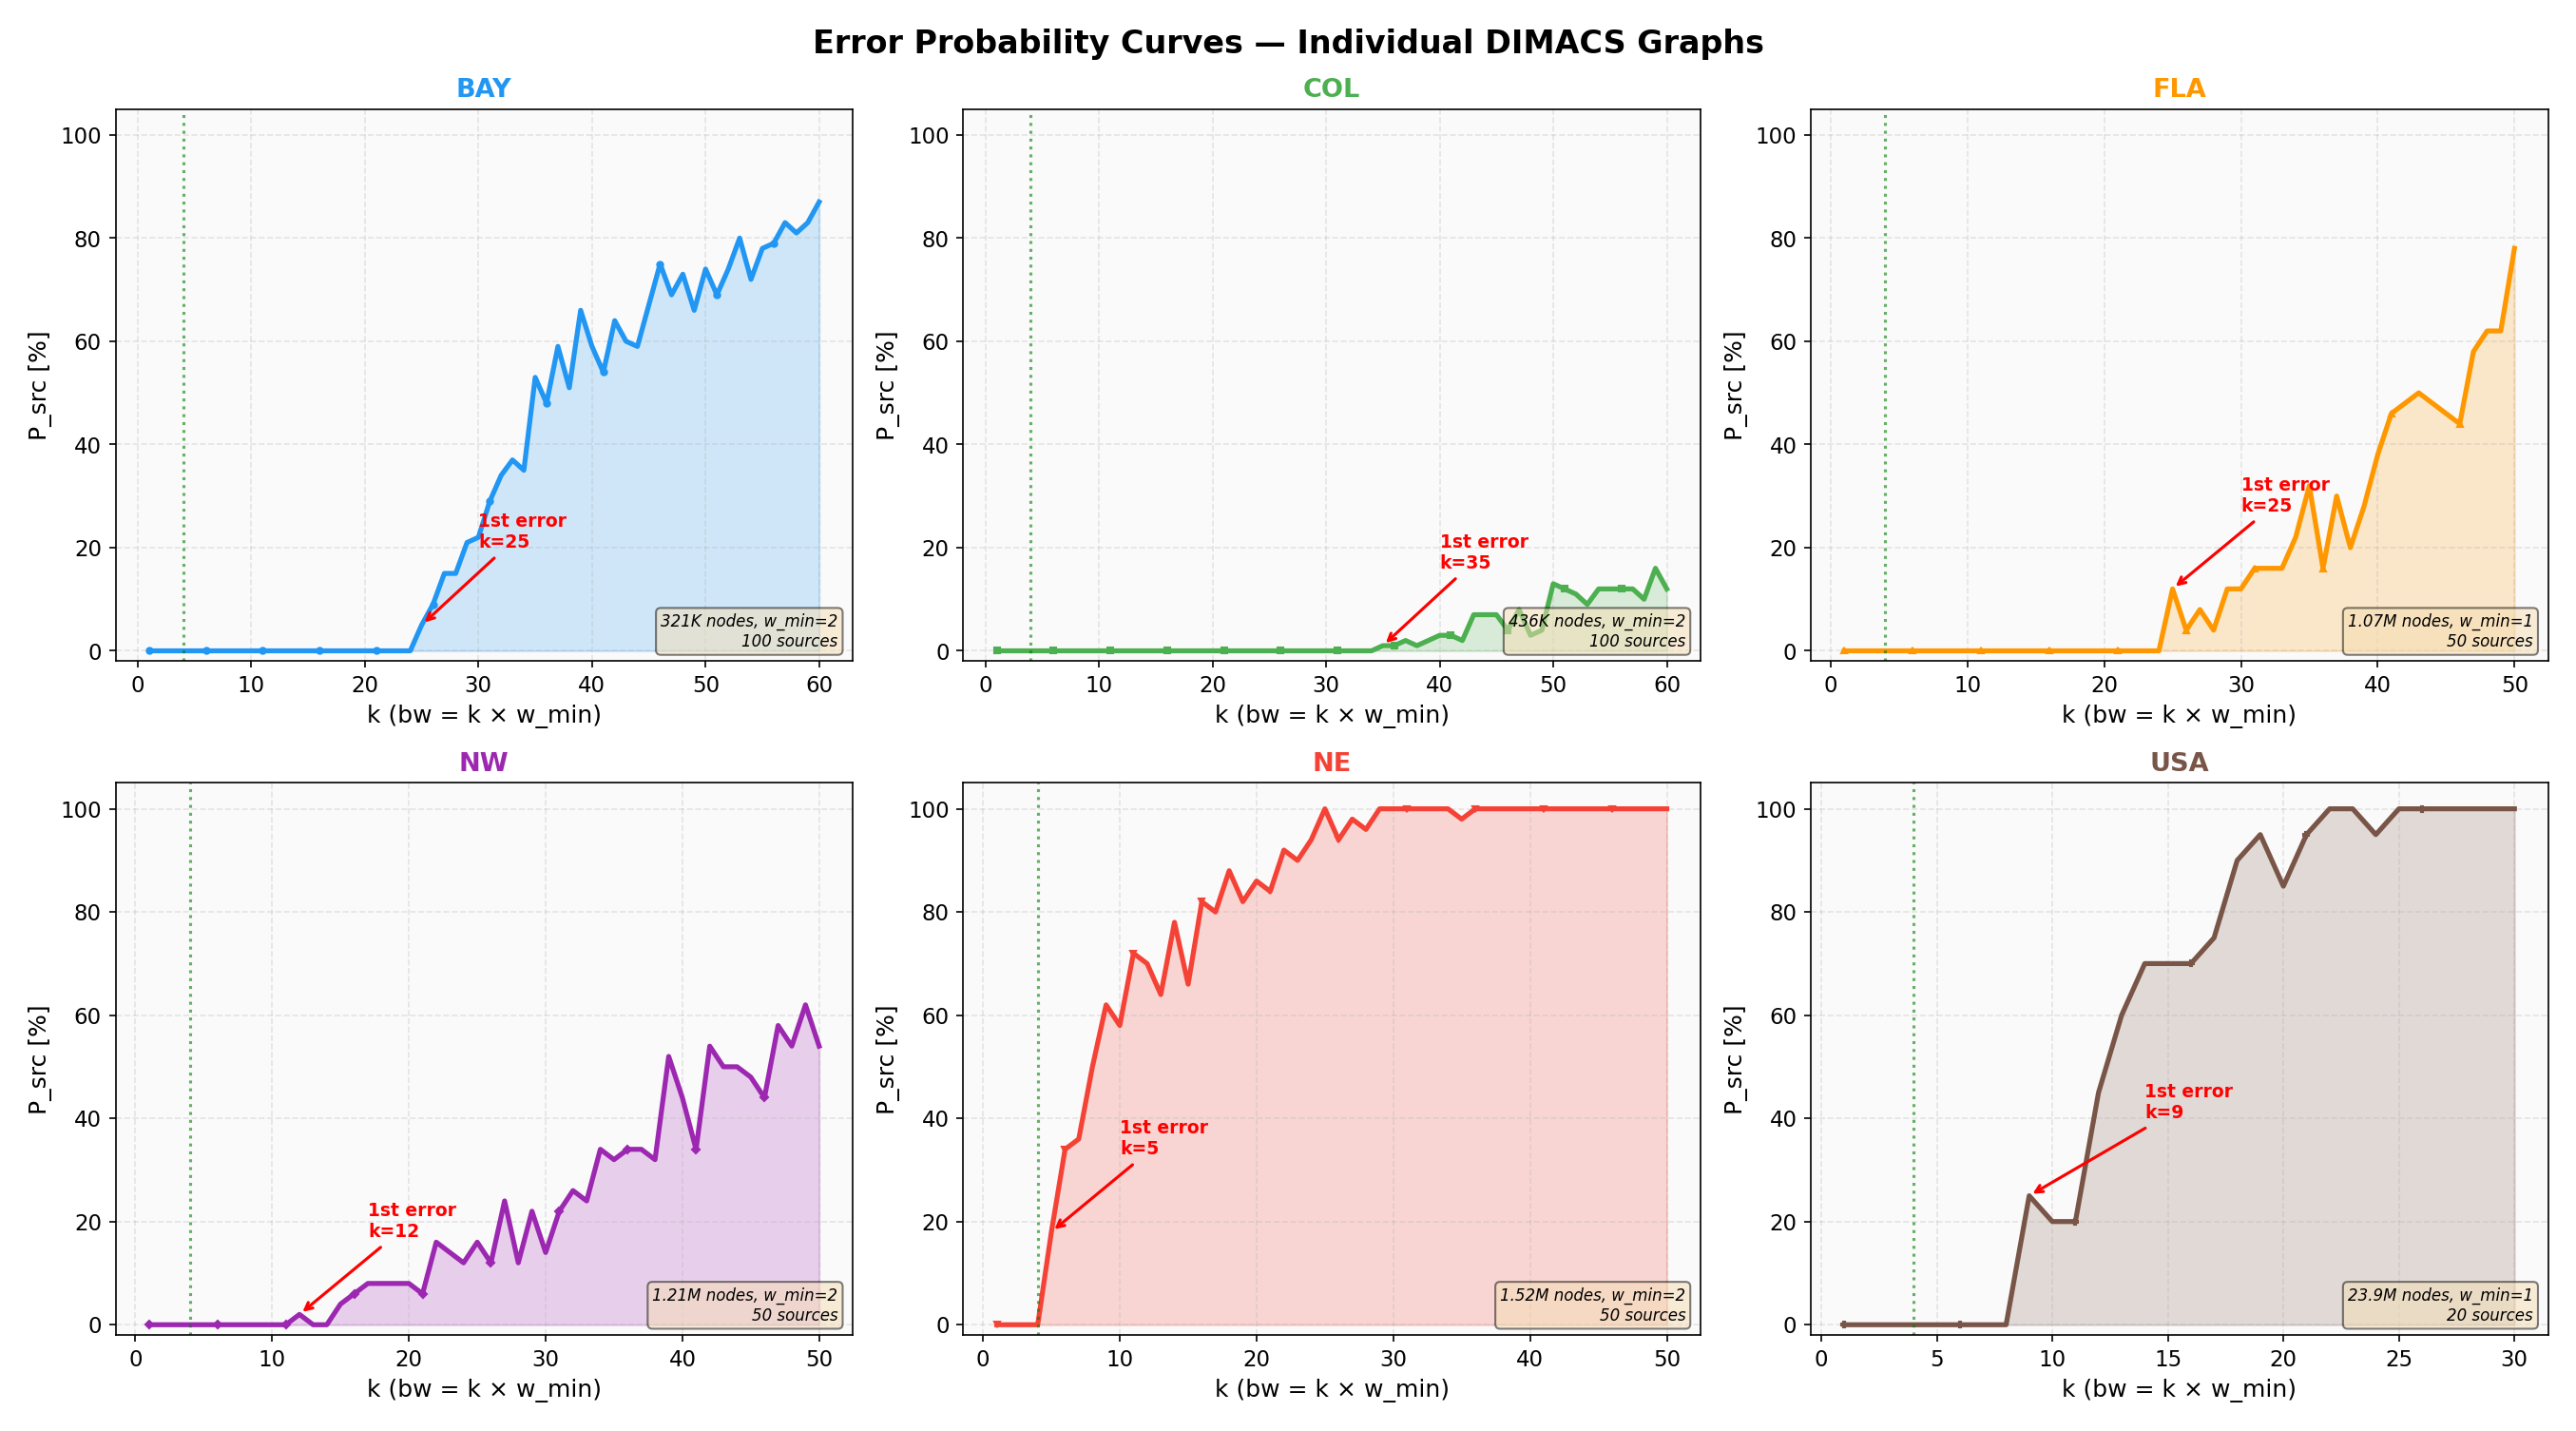

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Error Probability Curves — Individual DIMACS Graphs', fontsize=16, fontweight='bold')

datasets = [
    ('BAY', BAY_k, BAY_psrc, '321K nodes, w_min=2\n100 sources'),
    ('COL', COL_k, COL_psrc, '436K nodes, w_min=2\n100 sources'),
    ('FLA', FLA_k, FLA_psrc, '1.07M nodes, w_min=1\n50 sources'),
    ('NW', NW_k, NW_psrc, '1.21M nodes, w_min=2\n50 sources'),
    ('NE', NE_k, NE_psrc, '1.52M nodes, w_min=2\n50 sources'),
    ('USA', USA_k, USA_psrc, '23.9M nodes, w_min=1\n20 sources'),
]

for idx, (name, k, psrc, info) in enumerate(datasets):
    ax = axes[idx // 3][idx % 3]
    pct = [p * 100 for p in psrc]

    ax.fill_between(k, pct, alpha=0.2, color=COLORS[name])
    ax.plot(k, pct, color=COLORS[name], linewidth=2.5, marker=MARKERS[name],
            markersize=3, markevery=5)

    ax.axvline(x=4, color='green', linestyle=':', linewidth=1.5, alpha=0.6)

    first_err_k = next((ki for ki, p in zip(k, psrc) if p > 0), None)
    if first_err_k:
        first_err_p = psrc[k.index(first_err_k)] * 100
        ax.annotate(f'1st error\nk={first_err_k}',
                    xy=(first_err_k, first_err_p),
                    xytext=(first_err_k + 5, first_err_p + 15),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                    fontsize=9, color='red', fontweight='bold')

    ax.set_title(f'{name}', fontsize=13, fontweight='bold', color=COLORS[name])
    ax.set_xlabel('k (bw = k × w_min)')
    ax.set_ylabel('P_src [%]')
    ax.set_ylim(-2, 105)
    ax.text(0.98, 0.02, info, transform=ax.transAxes, fontsize=8,
            ha='right', va='bottom', style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.tight_layout()
plt.show()

---
## Figure 3 — `fig03_ne_phase_transition.png`
**The smoking gun.** Max errors per source jumps from 2 to 2,270 at k=17 — a 1,135× explosion.

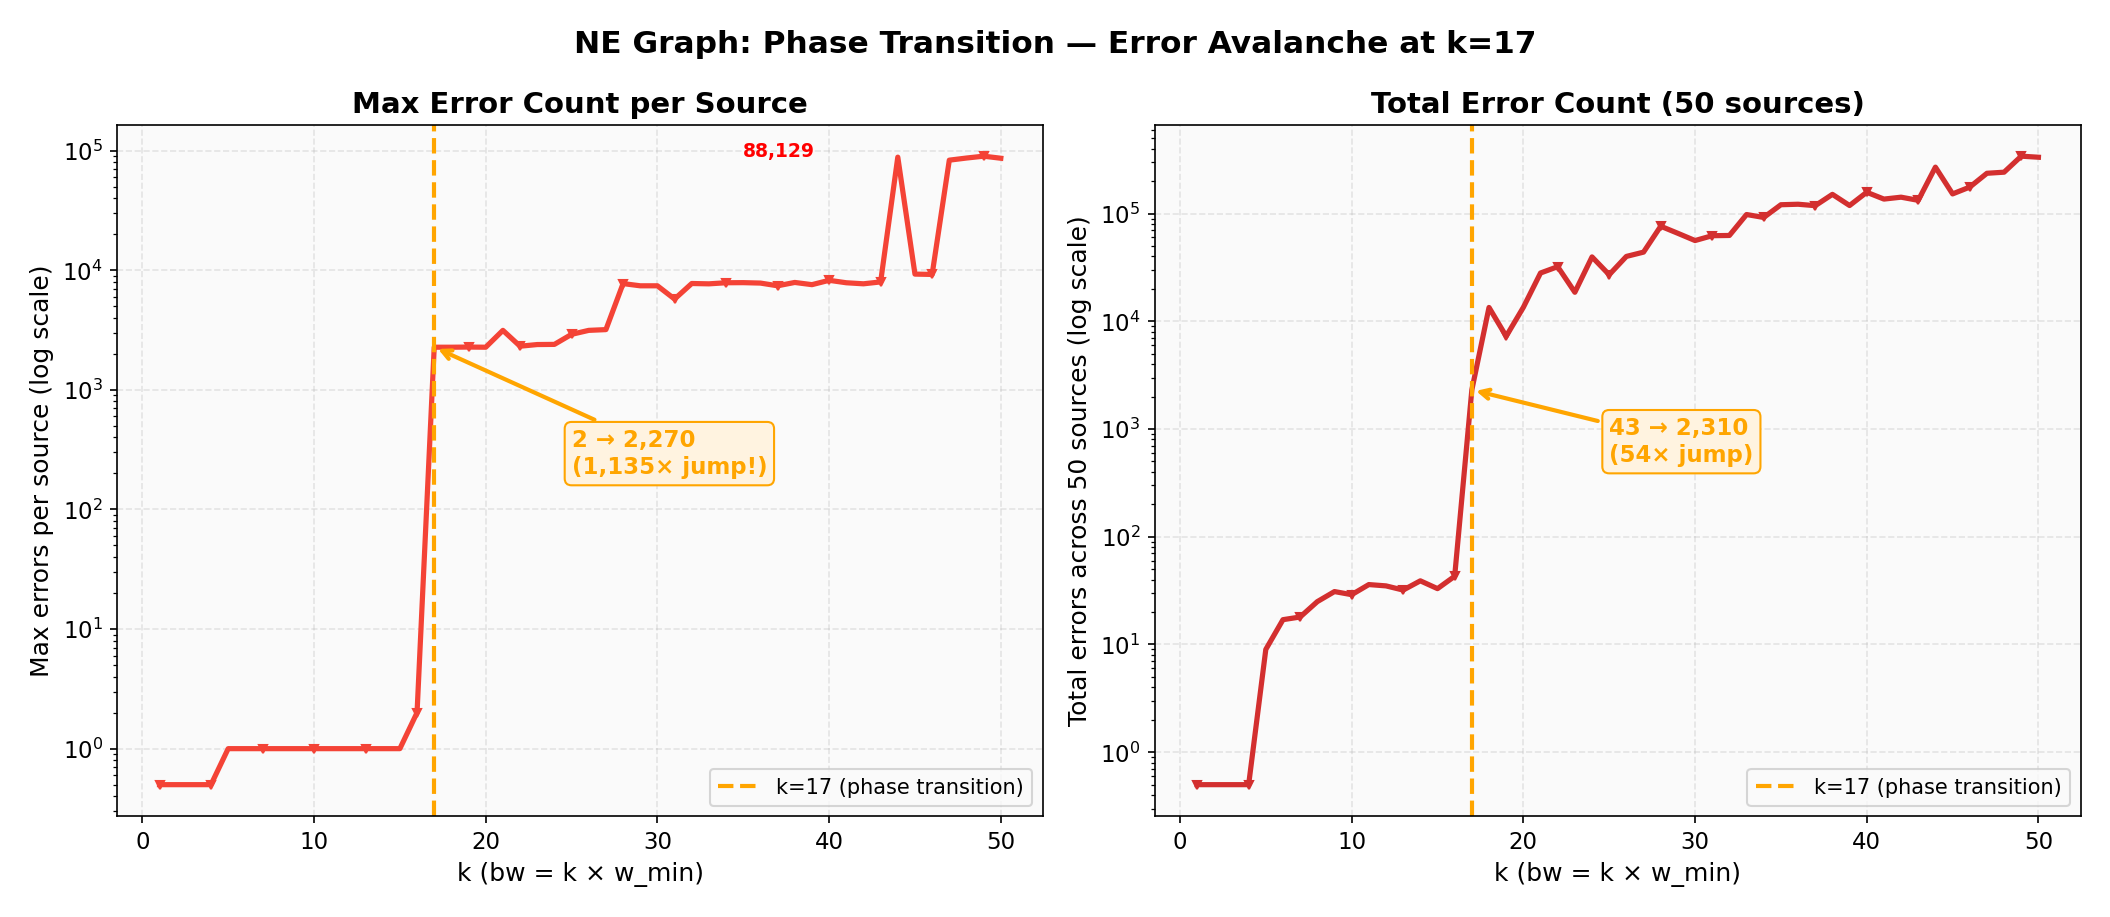

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('NE Graph: Phase Transition — Error Avalanche at k=17',
             fontsize=15, fontweight='bold')

k = NE_k

# Left: max errors per source (log scale)
ax1.semilogy(k, [max(e, 0.5) for e in NE_maxerr],
             color='#F44336', linewidth=2.5, marker='v', markersize=4, markevery=3)
ax1.axvline(x=17, color='orange', linestyle='--', linewidth=2, label='k=17 (phase transition)')
ax1.set_xlabel('k (bw = k × w_min)')
ax1.set_ylabel('Max errors per source (log scale)')
ax1.set_title('Max Error Count per Source')
ax1.legend()

ax1.annotate('2 → 2,270\n(1,135× jump!)',
             xy=(17, 2270), xytext=(25, 200),
             arrowprops=dict(arrowstyle='->', color='orange', lw=2),
             fontsize=11, fontweight='bold', color='orange',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='orange'))
ax1.annotate('88,129',
             xy=(44, 88129), xytext=(35, 88129),
             fontsize=9, fontweight='bold', color='red')

# Right: total errors across all sources
ax2.semilogy(k, [max(e, 0.5) for e in NE_totalerr],
             color='#D32F2F', linewidth=2.5, marker='v', markersize=4, markevery=3)
ax2.axvline(x=17, color='orange', linestyle='--', linewidth=2, label='k=17 (phase transition)')
ax2.set_xlabel('k (bw = k × w_min)')
ax2.set_ylabel('Total errors across 50 sources (log scale)')
ax2.set_title('Total Error Count (50 sources)')
ax2.legend()

ax2.annotate('43 → 2,310\n(54× jump)',
             xy=(17, 2310), xytext=(25, 500),
             arrowprops=dict(arrowstyle='->', color='orange', lw=2),
             fontsize=11, fontweight='bold', color='orange',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='orange'))

fig.tight_layout()
plt.show()

---
## Figure 4 — `fig04_boundary_sweep.png`
Safe/Fail bucket width across all 6 DIMACS graphs. V27 operating point at k=4.

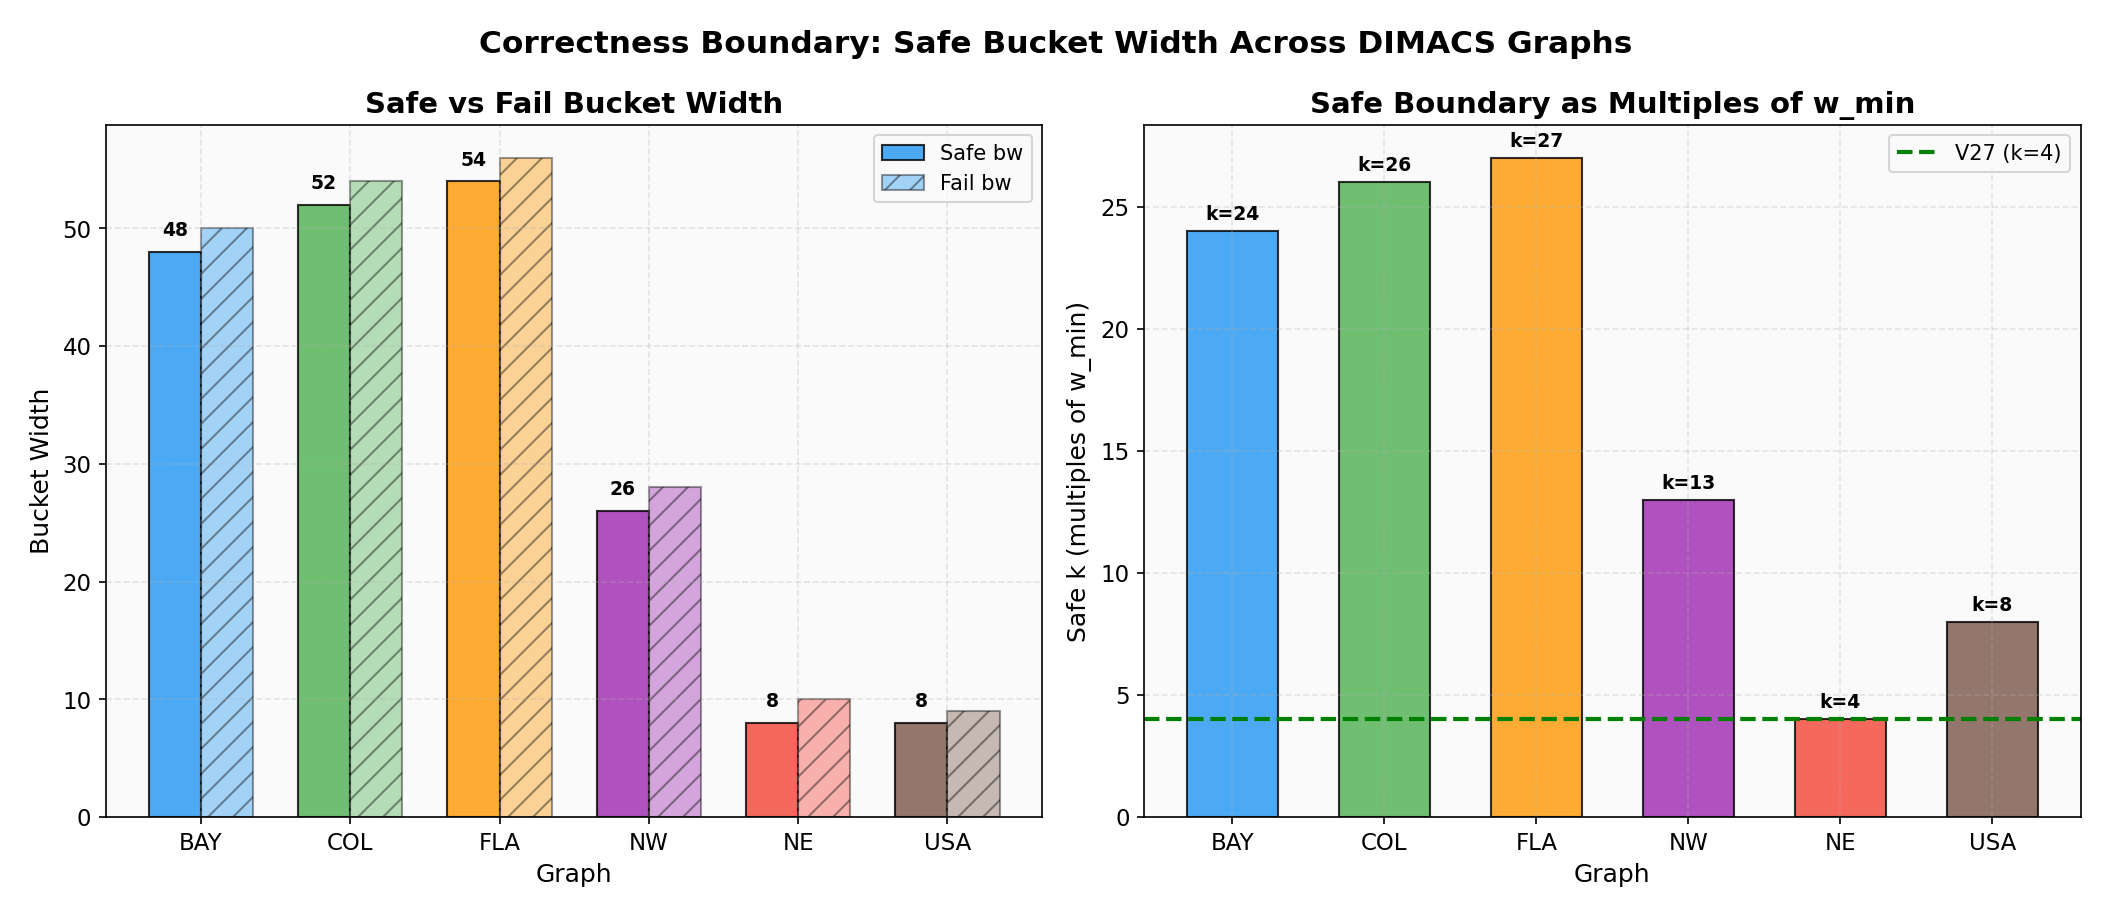

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correctness Boundary: Safe Bucket Width Across DIMACS Graphs',
             fontsize=15, fontweight='bold')

graphs = ['BAY', 'COL', 'FLA', 'NW', 'NE', 'USA']
safe_bw = [boundary_data[g][3] for g in graphs]
fail_bw = [boundary_data[g][4] for g in graphs]
safe_k = [boundary_data[g][5] for g in graphs]

x = np.arange(len(graphs))
width = 0.35

# Left: safe_bw (absolute)
bars1 = ax1.bar(x - width/2, safe_bw, width, label='Safe bw',
                color=[COLORS[g] for g in graphs], alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, fail_bw, width, label='Fail bw',
                color=[COLORS[g] for g in graphs], alpha=0.4, edgecolor='black',
                hatch='//')

ax1.set_xlabel('Graph')
ax1.set_ylabel('Bucket Width')
ax1.set_title('Safe vs Fail Bucket Width')
ax1.set_xticks(x)
ax1.set_xticklabels(graphs)
ax1.legend()

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: safe_k (multiples of w_min)
bars3 = ax2.bar(x, safe_k, 0.6, color=[COLORS[g] for g in graphs],
                edgecolor='black', alpha=0.8)
ax2.axhline(y=4, color='green', linestyle='--', linewidth=2, label='V27 (k=4)')
ax2.set_xlabel('Graph')
ax2.set_ylabel('Safe k (multiples of w_min)')
ax2.set_title('Safe Boundary as Multiples of w_min')
ax2.set_xticks(x)
ax2.set_xticklabels(graphs)
ax2.legend()

for bar, g in zip(bars3, graphs):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'k={int(bar.get_height())}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.tight_layout()
plt.show()

---
## Figure 5 — `fig05_conjecture_scorecard.png`
All 4 conjectures DISPROVEN. Predictions: 1–2, Actual: 8–54.

/tmp/ipykernel_763/4223161291.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


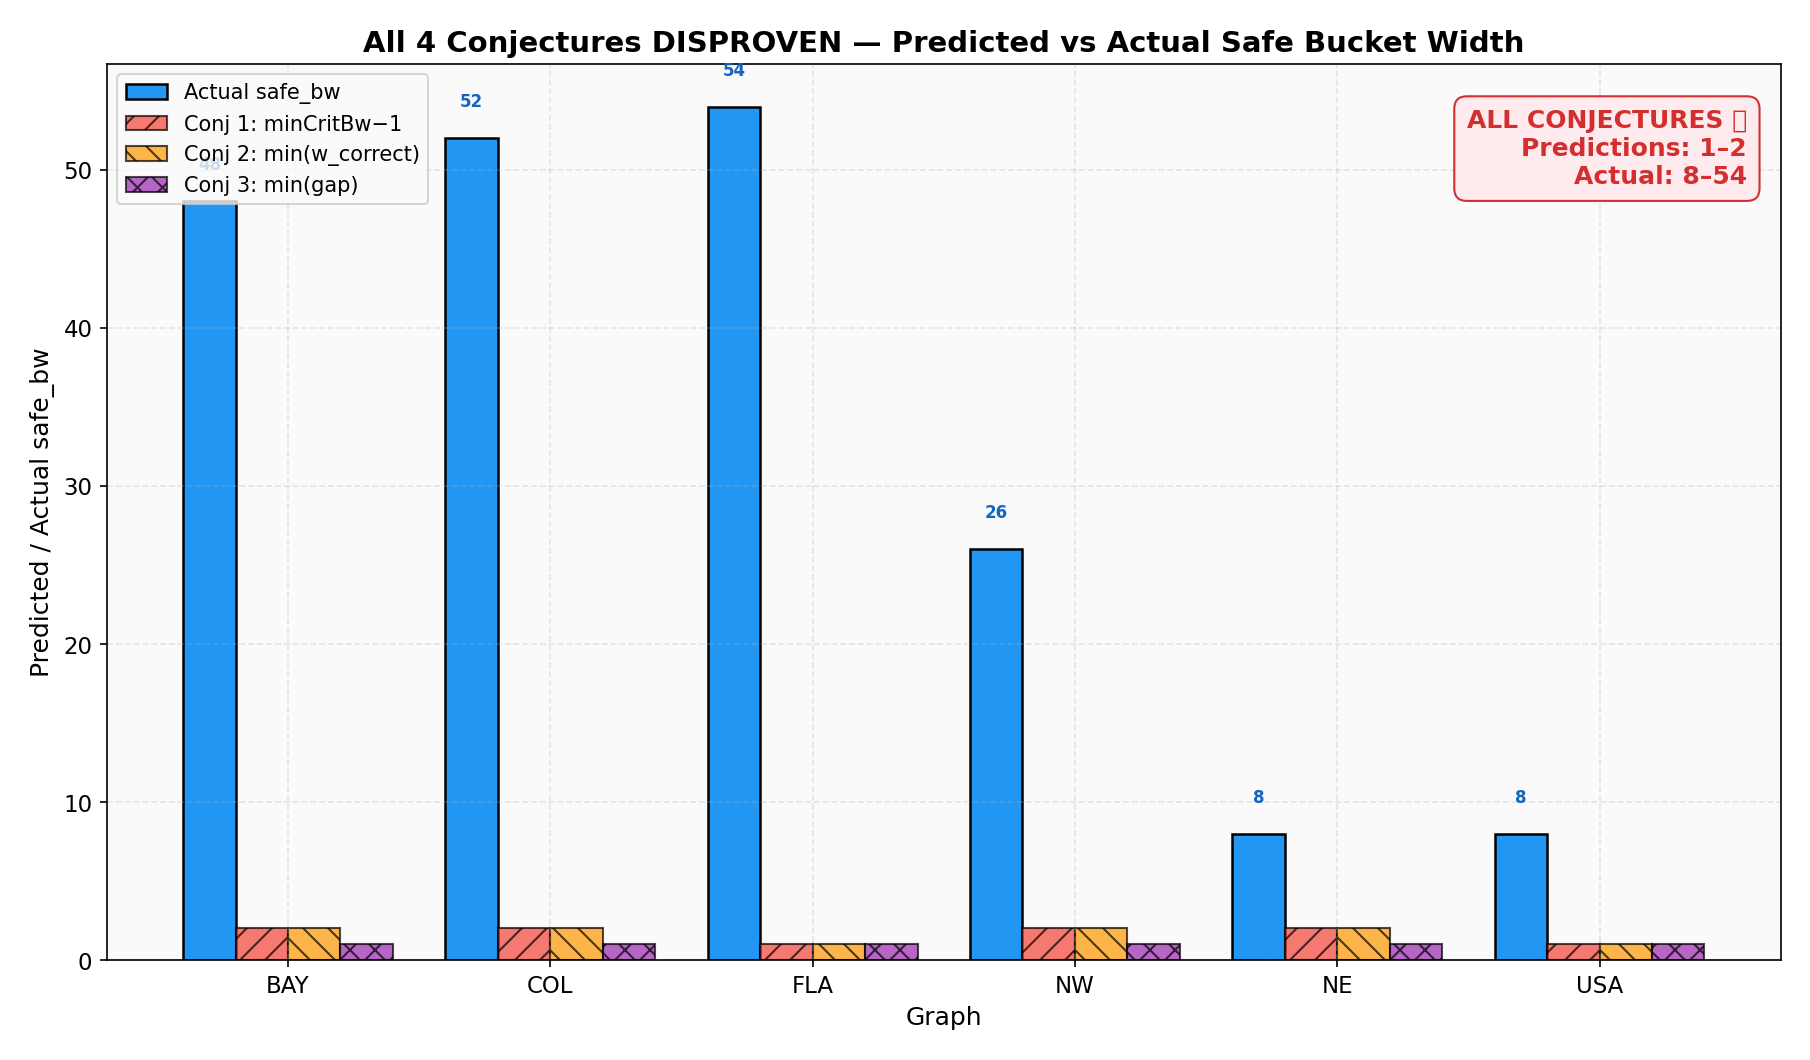

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

graphs = ['BAY', 'COL', 'FLA', 'NW', 'NE', 'USA']
actual = [conjecture_data[g][0] for g in graphs]
pred_critbw = [conjecture_data[g][1] for g in graphs]
pred_wcorr = [conjecture_data[g][2] for g in graphs]
pred_gap = [conjecture_data[g][3] for g in graphs]

x = np.arange(len(graphs))
width = 0.2

ax.bar(x - 1.5*width, actual, width, label='Actual safe_bw',
       color='#2196F3', edgecolor='black', linewidth=1.2)
ax.bar(x - 0.5*width, pred_critbw, width, label='Conj 1: minCritBw−1',
       color='#F44336', edgecolor='black', alpha=0.7, hatch='//')
ax.bar(x + 0.5*width, pred_wcorr, width, label='Conj 2: min(w_correct)',
       color='#FF9800', edgecolor='black', alpha=0.7, hatch='\\\\')
ax.bar(x + 1.5*width, pred_gap, width, label='Conj 3: min(gap)',
       color='#9C27B0', edgecolor='black', alpha=0.7, hatch='xx')

ax.set_xlabel('Graph')
ax.set_ylabel('Predicted / Actual safe_bw')
ax.set_title('All 4 Conjectures DISPROVEN — Predicted vs Actual Safe Bucket Width')
ax.set_xticks(x)
ax.set_xticklabels(graphs)
ax.legend(loc='upper left')

for i, g in enumerate(graphs):
    ax.annotate(f'{actual[i]}', xy=(i - 1.5*width, actual[i]),
                xytext=(i - 1.5*width, actual[i] + 2),
                ha='center', fontsize=8, fontweight='bold', color='#1565C0')

ax.text(0.98, 0.95, 'ALL CONJECTURES ❌\nPredictions: 1–2\nActual: 8–54',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        va='top', ha='right', color='#D32F2F',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFEBEE', edgecolor='#D32F2F'))

plt.tight_layout()
plt.show()

---
## Figure 6 — `fig06_collision_vs_error.png`
**Collision ≠ Error.** COL has 11,171 collisions but ZERO errors.

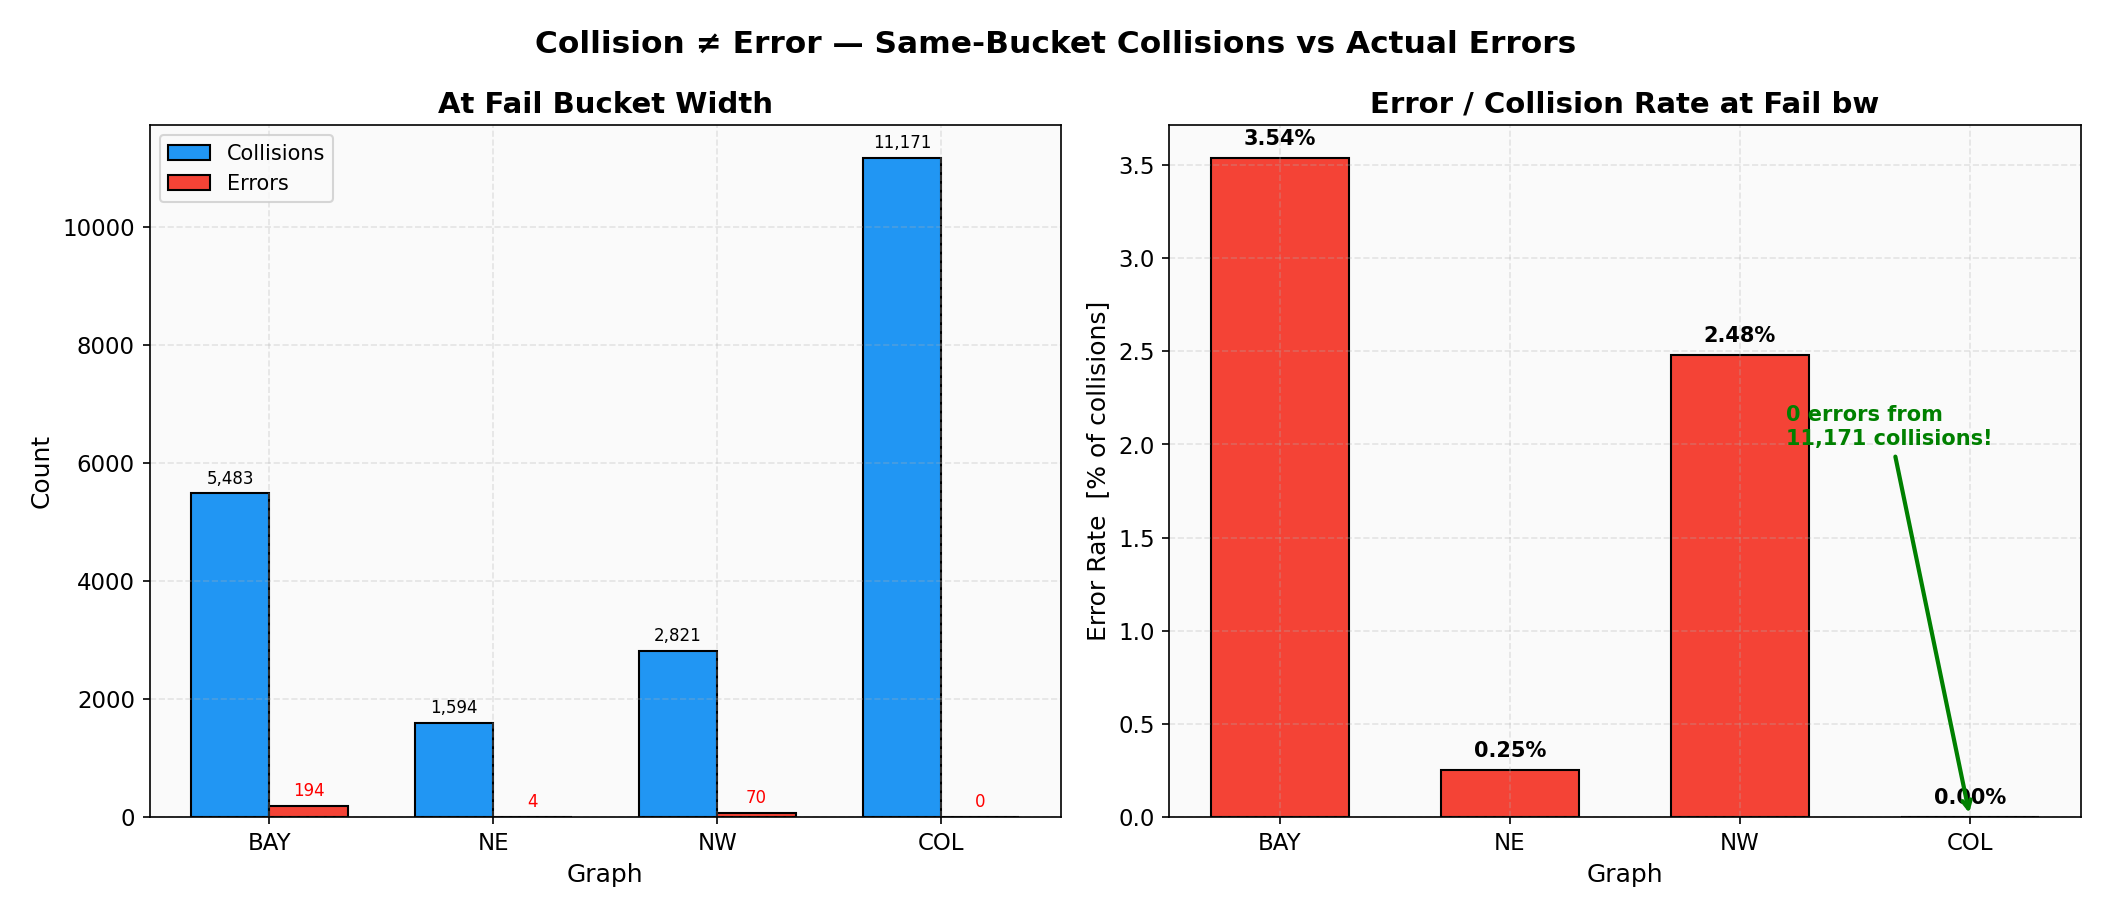

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Collision ≠ Error — Same-Bucket Collisions vs Actual Errors',
             fontsize=15, fontweight='bold')

graphs = ['BAY', 'NE', 'NW', 'COL']
x = np.arange(len(graphs))
width = 0.35

coll_fail = [collision_data[g][2] for g in graphs]
err_fail = [collision_data[g][3] for g in graphs]

bars1 = ax1.bar(x - width/2, coll_fail, width, label='Collisions',
                color='#2196F3', edgecolor='black')
bars2 = ax1.bar(x + width/2, err_fail, width, label='Errors',
                color='#F44336', edgecolor='black')

ax1.set_xlabel('Graph')
ax1.set_ylabel('Count')
ax1.set_title('At Fail Bucket Width')
ax1.set_xticks(x)
ax1.set_xticklabels(graphs)
ax1.legend()

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8, color='red')

# Right: error rate as percentage of collisions
err_rate = []
for g in graphs:
    c = collision_data[g][2]
    e = collision_data[g][3]
    err_rate.append((e / c * 100) if c > 0 else 0)

colors_rate = ['#F44336' if r > 0 else '#4CAF50' for r in err_rate]
bars3 = ax2.bar(x, err_rate, 0.6, color=colors_rate, edgecolor='black')
ax2.set_xlabel('Graph')
ax2.set_ylabel('Error Rate  [% of collisions]')
ax2.set_title('Error / Collision Rate at Fail bw')
ax2.set_xticks(x)
ax2.set_xticklabels(graphs)

for bar, rate in zip(bars3, err_rate):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{rate:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.annotate('0 errors from\n11,171 collisions!',
             xy=(3, 0), xytext=(2.2, 2.0),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=10, fontweight='bold', color='green')

fig.tight_layout()
plt.show()

---
## Figure 7 — `fig07_family1_ratio.png`
safe_bw/W ratio is NOT constant (1.5× to 75×). No linear formula works.

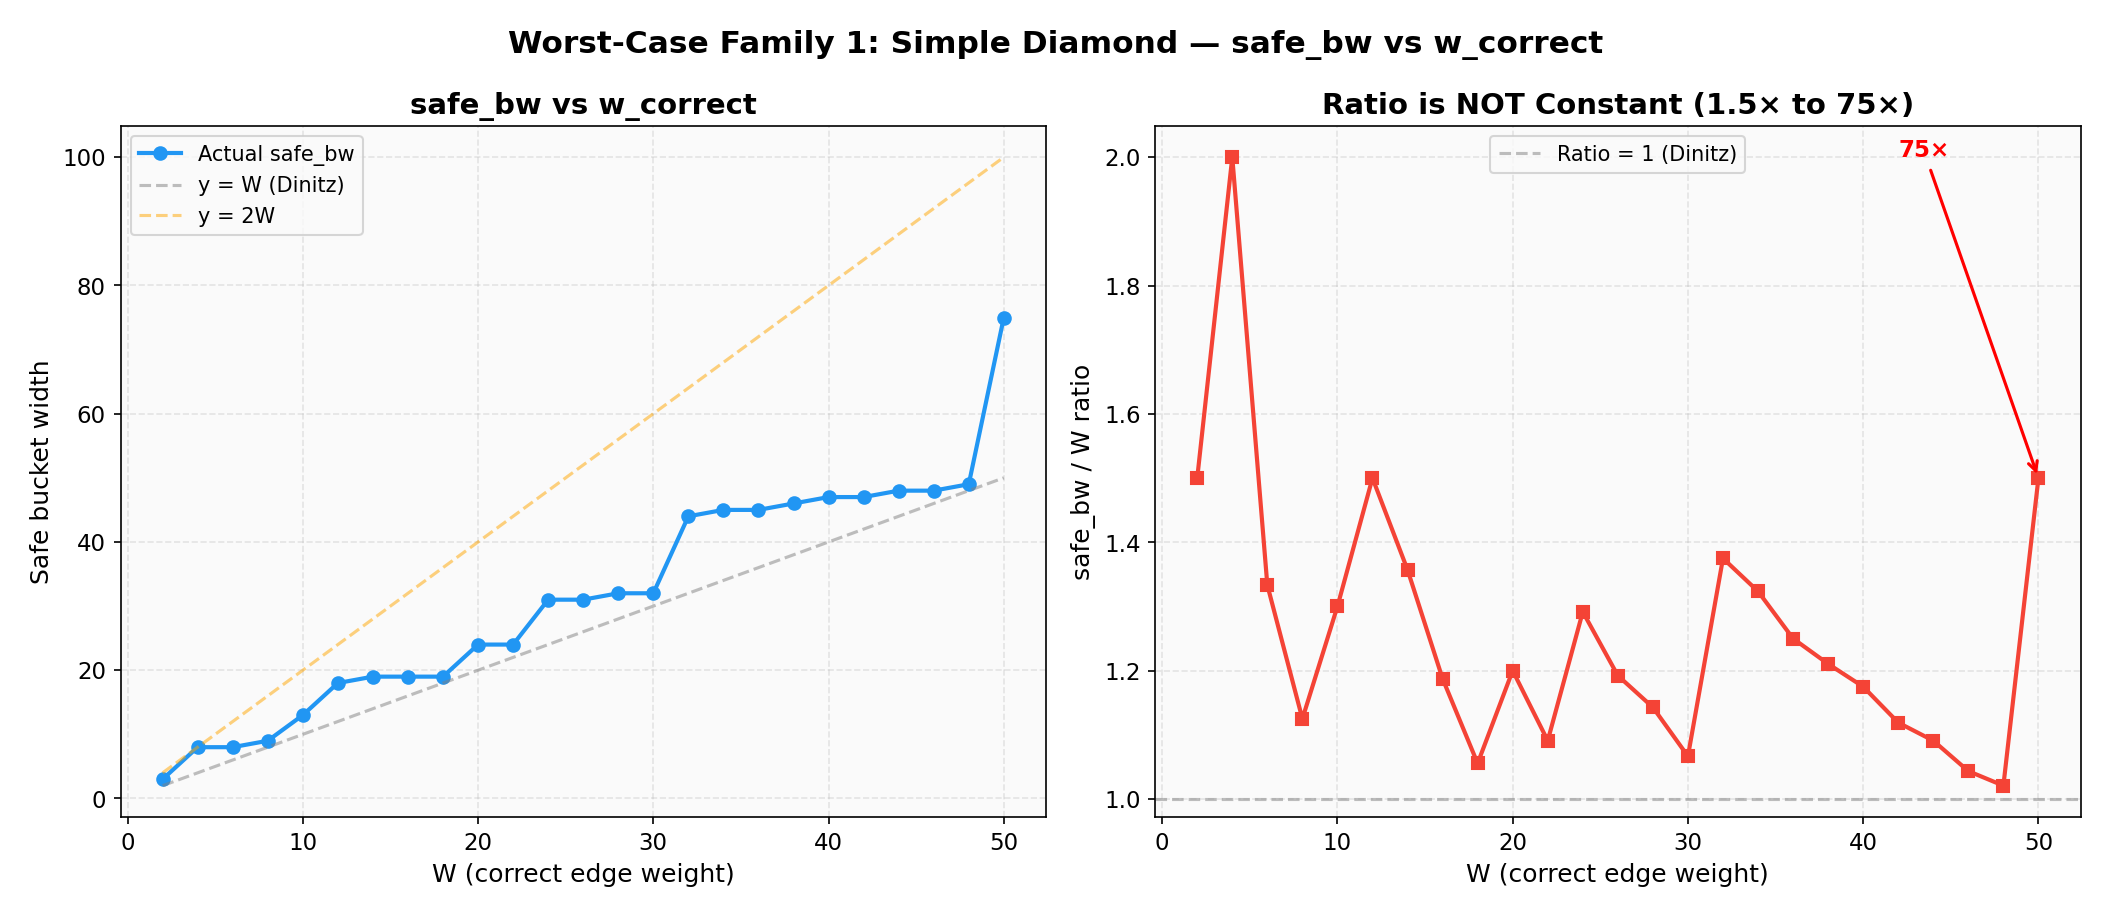

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Worst-Case Family 1: Simple Diamond — safe_bw vs w_correct',
             fontsize=15, fontweight='bold')

# Left: safe_bw vs W
ax1.plot(family1_W, family1_safe, 'o-', color='#2196F3', linewidth=2, markersize=6,
         label='Actual safe_bw')
ax1.plot(family1_W, family1_W, '--', color='gray', alpha=0.5, label='y = W (Dinitz)')
ax1.plot(family1_W, [w*2 for w in family1_W], '--', color='orange', alpha=0.5, label='y = 2W')

ax1.set_xlabel('W (correct edge weight)')
ax1.set_ylabel('Safe bucket width')
ax1.set_title('safe_bw vs w_correct')
ax1.legend()

# Right: ratio safe_bw / W
ax2.plot(family1_W, family1_ratio, 's-', color='#F44336', linewidth=2, markersize=6)
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Ratio = 1 (Dinitz)')

ax2.set_xlabel('W (correct edge weight)')
ax2.set_ylabel('safe_bw / W ratio')
ax2.set_title('Ratio is NOT Constant (1.5× to 75×)')
ax2.legend()

ax2.annotate(f'75×', xy=(50, 75/50), xytext=(42, 2.0),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11, fontweight='bold', color='red')

fig.tight_layout()
plt.show()

---
## Figure 8 — `fig08_family3_nonmonotonic.png`
**Non-monotonic errors.** Errors appear at bw=9, disappear at bw=13, reappear at bw=14.

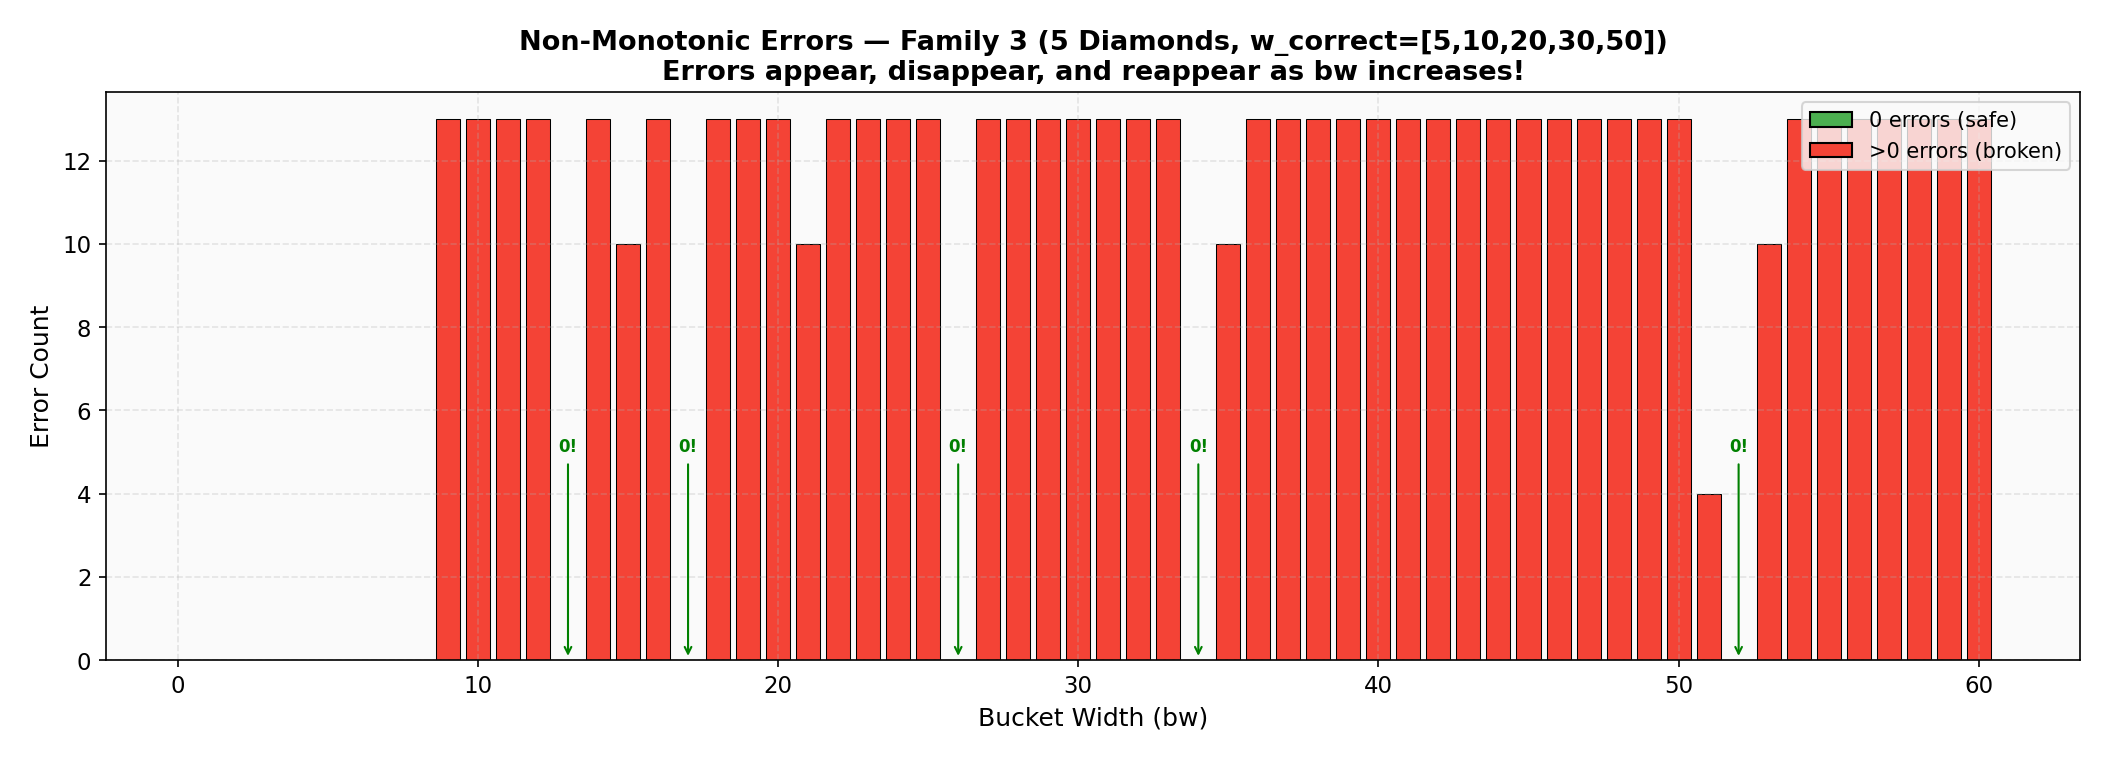

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#4CAF50' if e == 0 else '#F44336' for e in family3_errors]

ax.bar(family3_bw, family3_errors, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Bucket Width (bw)')
ax.set_ylabel('Error Count')
ax.set_title('Non-Monotonic Errors — Family 3 (5 Diamonds, w_correct=[5,10,20,30,50])\n'
             'Errors appear, disappear, and reappear as bw increases!',
             fontsize=13, fontweight='bold')

zero_runs = [(13, '0'), (17, '0'), (26, '0'), (34, '0'), (52, '0')]
for bw_val, label in zero_runs:
    ax.annotate('0!', xy=(bw_val, 0), xytext=(bw_val, 5),
                ha='center', fontsize=8, fontweight='bold', color='green',
                arrowprops=dict(arrowstyle='->', color='green', lw=1))

legend_elements = [Patch(facecolor='#4CAF50', edgecolor='black', label='0 errors (safe)'),
                   Patch(facecolor='#F44336', edgecolor='black', label='>0 errors (broken)')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

---
## Figure 9 — `fig09_family5_gap.png`
Larger gap → larger safe_bw, but in a staircase pattern with jumps.

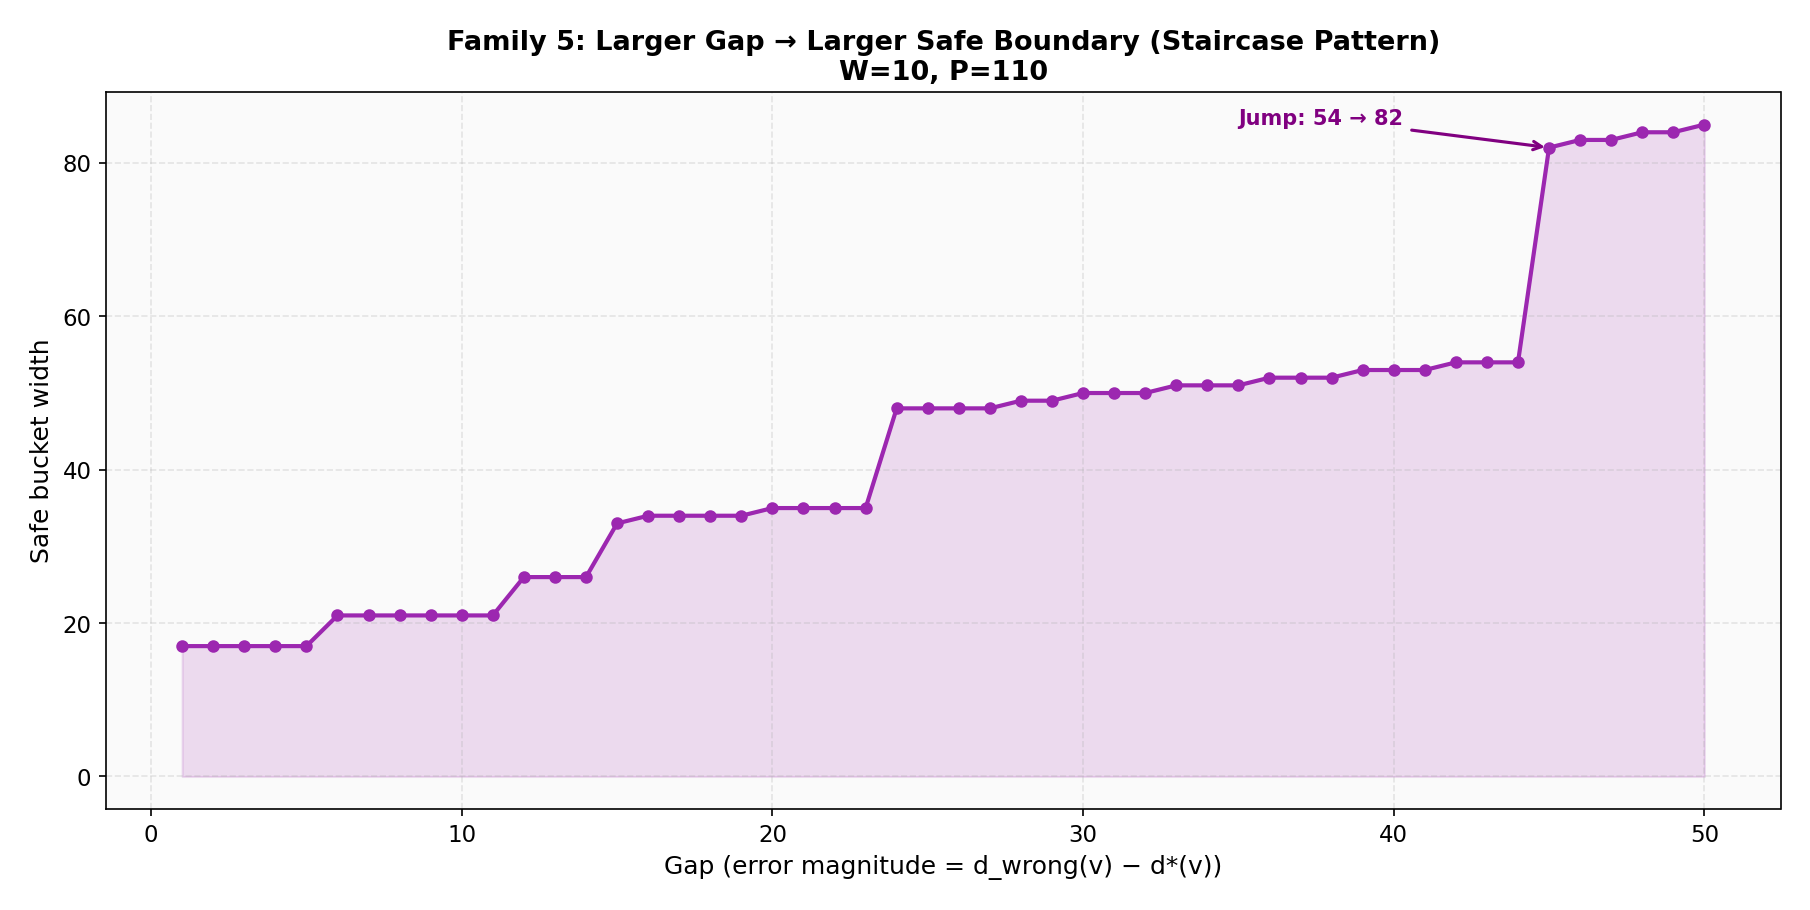

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(family5_gap, family5_safe, 'o-', color='#9C27B0', linewidth=2, markersize=5)
ax.fill_between(family5_gap, family5_safe, alpha=0.15, color='#9C27B0')

ax.set_xlabel('Gap (error magnitude = d_wrong(v) − d*(v))')
ax.set_ylabel('Safe bucket width')
ax.set_title('Family 5: Larger Gap → Larger Safe Boundary (Staircase Pattern)\n'
             'W=10, P=110', fontsize=13, fontweight='bold')

ax.annotate('Jump: 54 → 82', xy=(45, 82), xytext=(35, 85),
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.5),
            fontsize=10, fontweight='bold', color='purple')

plt.tight_layout()
plt.show()

---
## Figure 10 — `fig10_v27_performance.png`
V18 vs V27 speedup. V18 is faster but incorrect on USA (❌). V27 trades ~20% for 100% correctness.

/tmp/ipykernel_763/3821299972.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/3821299972.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


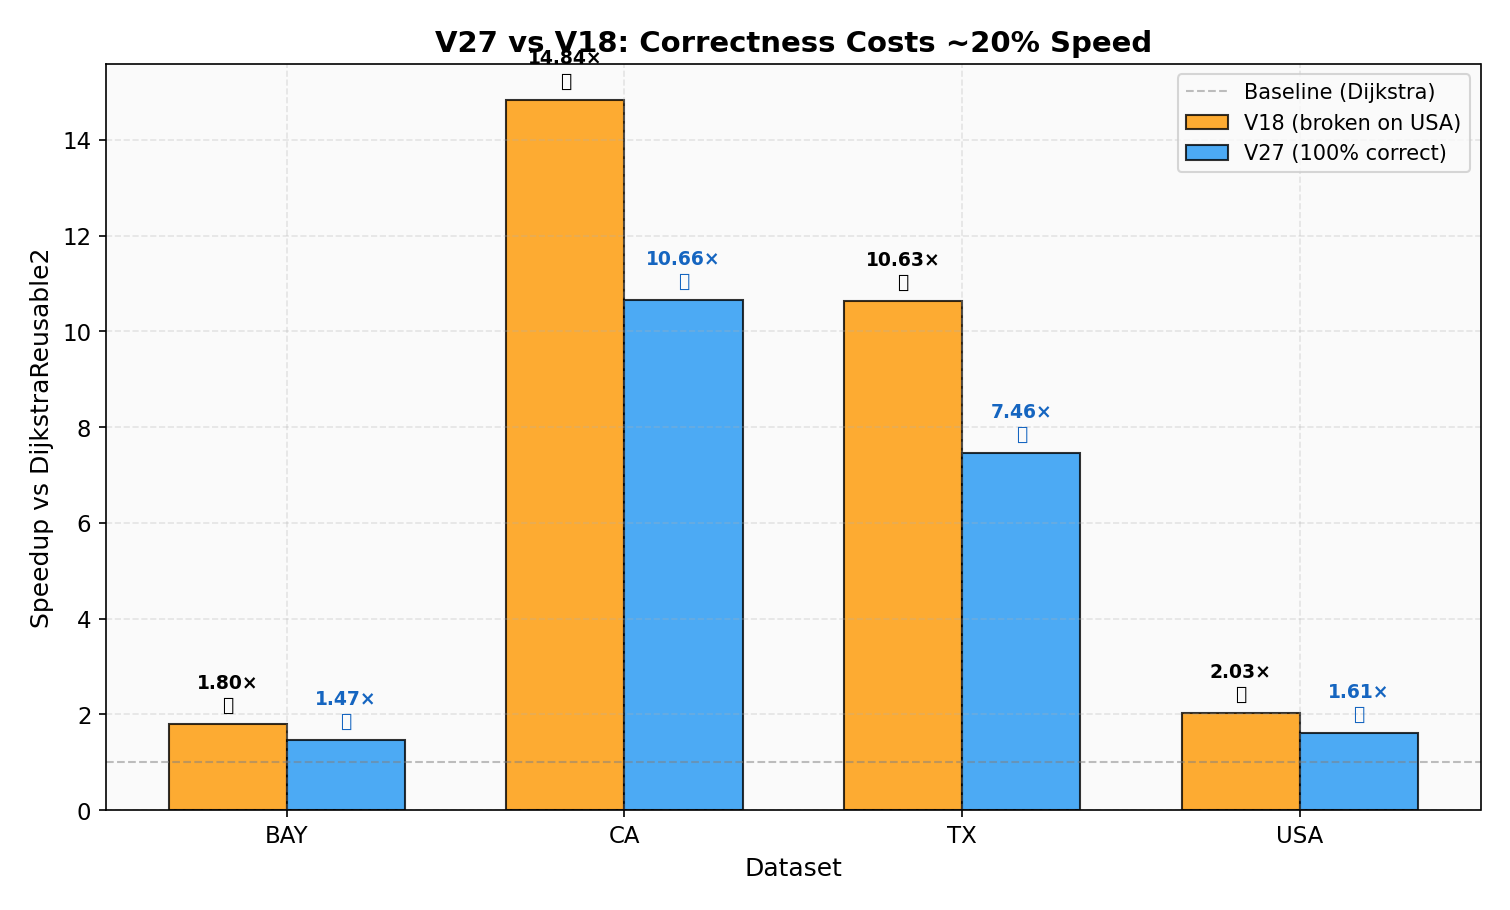

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

datasets_perf = list(v27_perf.keys())
v18_speeds = [v27_perf[d][0] for d in datasets_perf]
v27_speeds = [v27_perf[d][1] for d in datasets_perf]
v18_correct = [v27_perf[d][2] for d in datasets_perf]
v27_correct = [v27_perf[d][3] for d in datasets_perf]

x = np.arange(len(datasets_perf))
width = 0.35

bars1 = ax.bar(x - width/2, v18_speeds, width, label='V18 (broken on USA)',
               color='#FF9800', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, v27_speeds, width, label='V27 (100% correct)',
               color='#2196F3', edgecolor='black', alpha=0.8)

ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Baseline (Dijkstra)')

ax.set_xlabel('Dataset')
ax.set_ylabel('Speedup vs DijkstraReusable2')
ax.set_title('V27 vs V18: Correctness Costs ~20% Speed',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets_perf)
ax.legend()

for i, (bar, correct) in enumerate(zip(bars1, v18_correct)):
    symbol = '✅' if correct else '❌'
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.2f}×\n{symbol}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

for i, (bar, correct) in enumerate(zip(bars2, v27_correct)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.2f}×\n✅', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#1565C0')

plt.tight_layout()
plt.show()

---
## Figure 11 — `fig11_version_evolution.png`
The 27-version journey from V1 (baseline) to V27 (correct champion).

/tmp/ipykernel_763/2301447208.py:51: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/2301447208.py:51: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


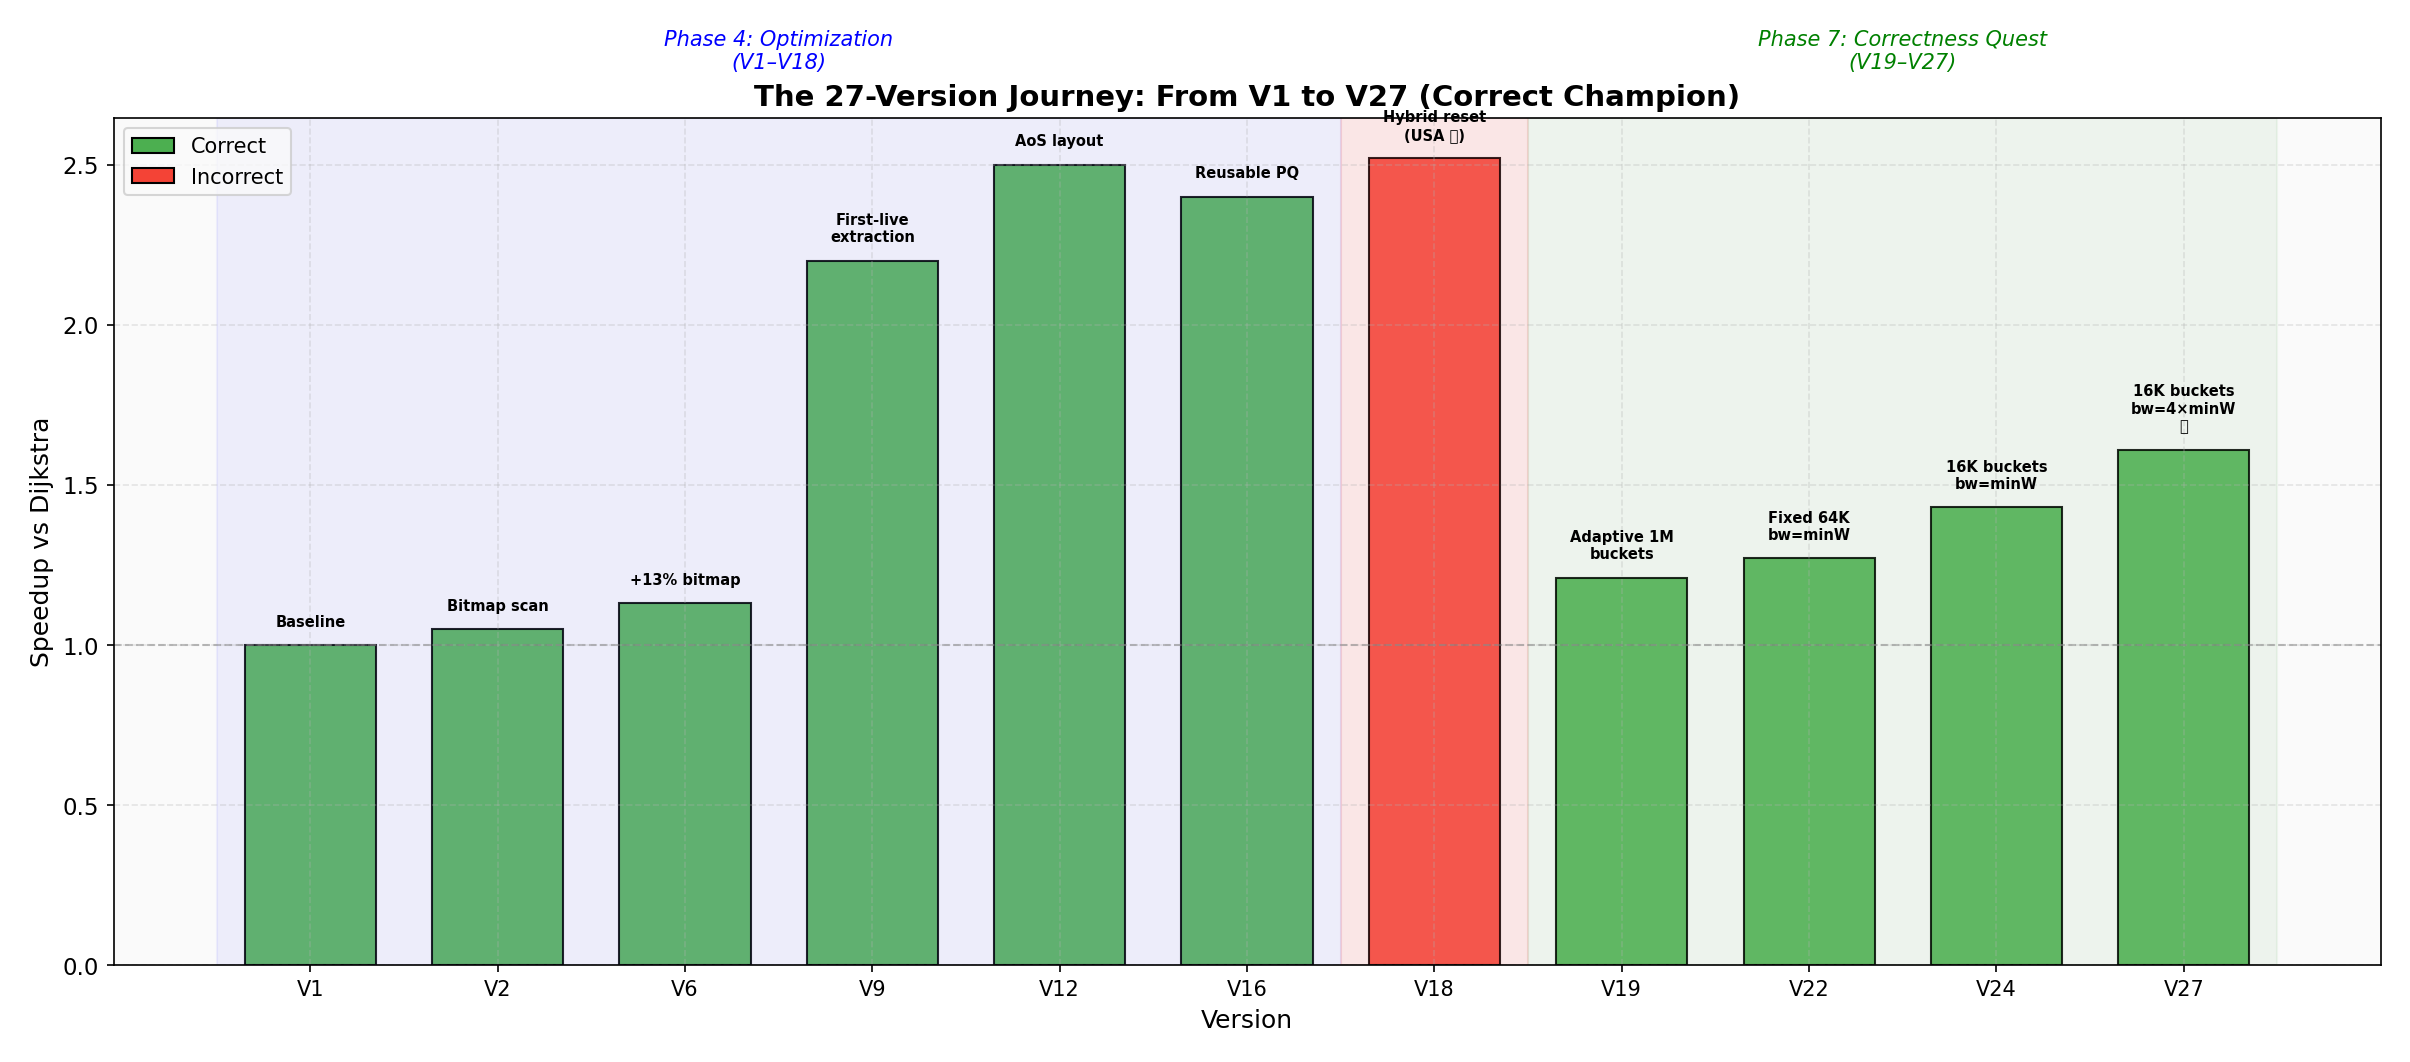

In [14]:
fig, ax = plt.subplots(figsize=(16, 7))

versions = ['V1', 'V2', 'V6', 'V9', 'V12', 'V16', 'V18', 'V19', 'V22', 'V24', 'V27']
speedups = [1.0, 1.05, 1.13, 2.2, 2.5, 2.4, 2.52, 1.21, 1.27, 1.43, 1.61]
correct  = [True, True, True, True, True, True, False, True, True, True, True]
labels = [
    'Baseline',
    'Bitmap scan',
    '+13% bitmap',
    'First-live\nextraction',
    'AoS layout',
    'Reusable PQ',
    'Hybrid reset\n(USA ❌)',
    'Adaptive 1M\nbuckets',
    'Fixed 64K\nbw=minW',
    '16K buckets\nbw=minW',
    '16K buckets\nbw=4×minW\n🏆'
]

colors_v = ['#4CAF50' if c else '#F44336' for c in correct]

x = np.arange(len(versions))
bars = ax.bar(x, speedups, color=colors_v, edgecolor='black', alpha=0.85, width=0.7)

ax.set_xlabel('Version')
ax.set_ylabel('Speedup vs Dijkstra')
ax.set_title('The 27-Version Journey: From V1 to V27 (Correct Champion)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions, fontsize=10)

for i, (bar, label) in enumerate(zip(bars, labels)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            label, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.axvspan(-0.5, 5.5, alpha=0.05, color='blue')
ax.axvspan(5.5, 6.5, alpha=0.08, color='red')
ax.axvspan(6.5, 10.5, alpha=0.05, color='green')

ax.text(2.5, 2.8, 'Phase 4: Optimization\n(V1–V18)', ha='center',
        fontsize=10, style='italic', color='blue')
ax.text(8.5, 2.8, 'Phase 7: Correctness Quest\n(V19–V27)', ha='center',
        fontsize=10, style='italic', color='green')

legend_elements = [Patch(facecolor='#4CAF50', edgecolor='black', label='Correct'),
                   Patch(facecolor='#F44336', edgecolor='black', label='Incorrect')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

---
## Figure 12 — `fig12_two_regimes.png`
Side-by-side: steep sigmoid (NE, USA) vs gradual rise (BAY, COL, FLA, NW).

/tmp/ipykernel_763/4110309194.py:43: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_763/4110309194.py:43: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


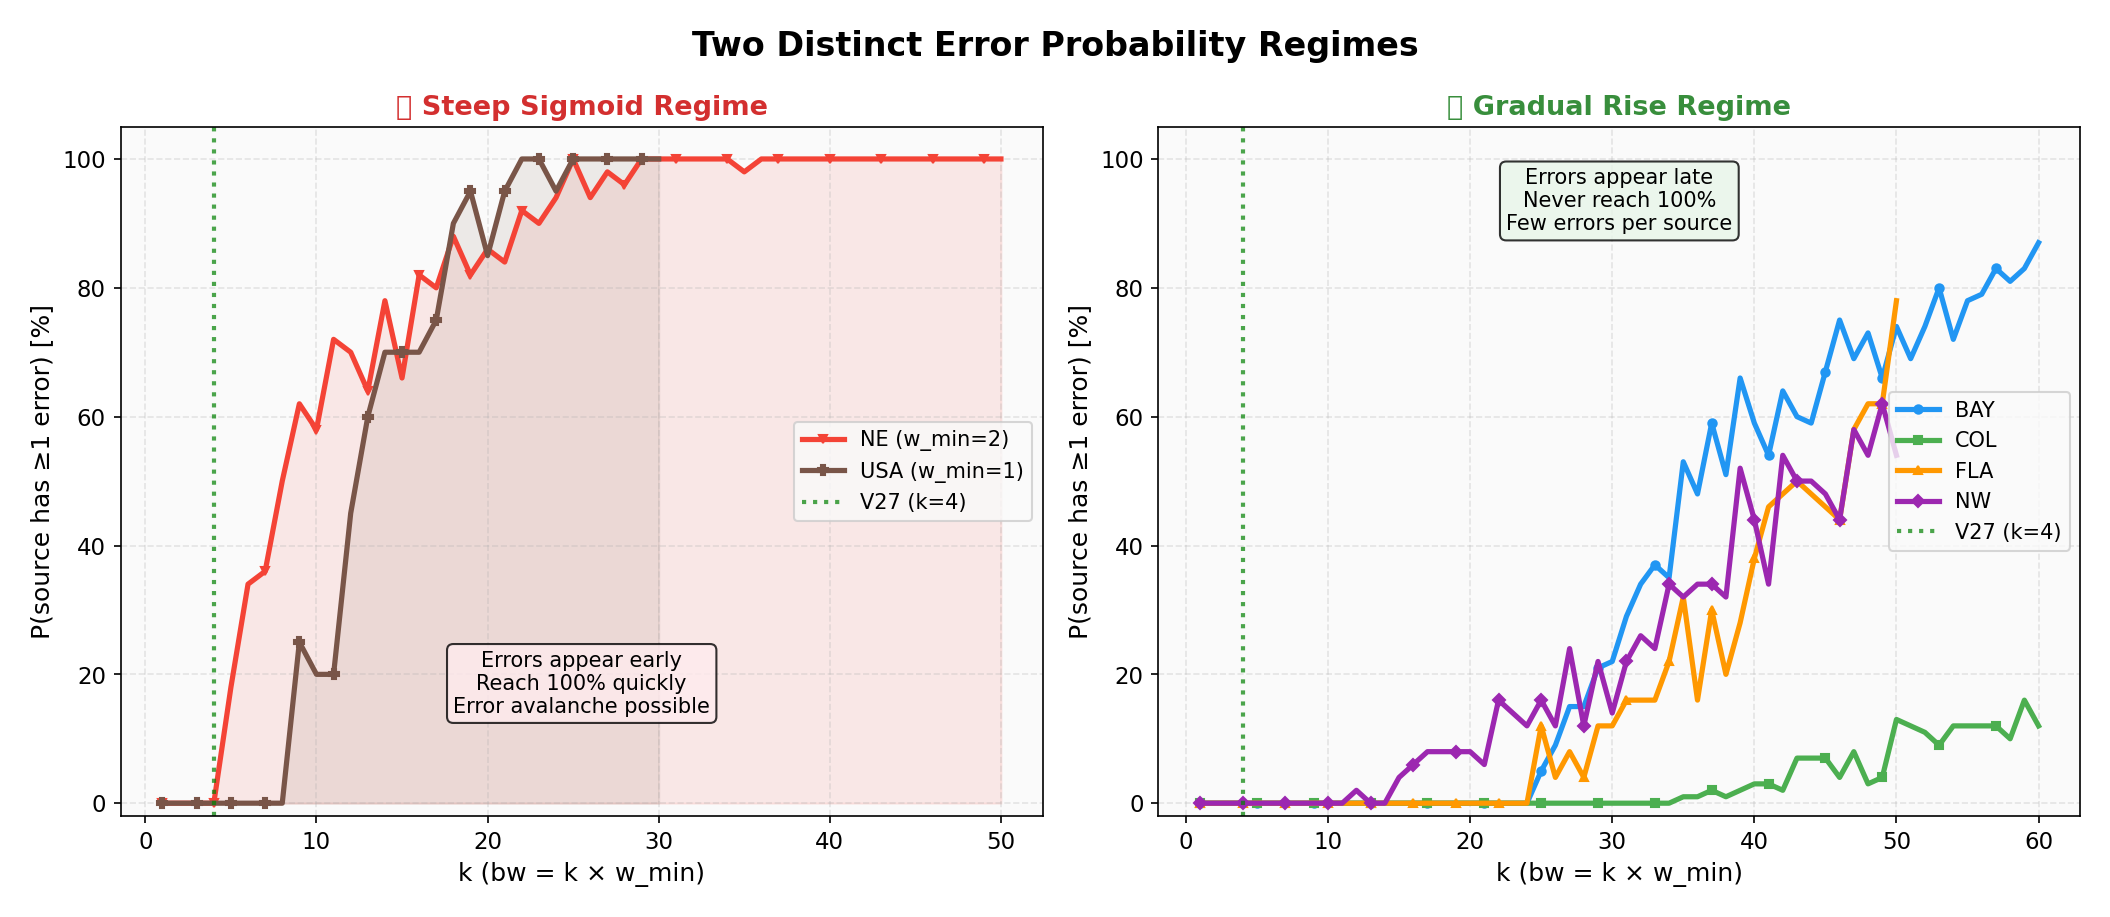

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Two Distinct Error Probability Regimes',
             fontsize=16, fontweight='bold')

# Left: Steep Sigmoid (NE, USA)
ax1.plot(NE_k, [p*100 for p in NE_psrc], color=COLORS['NE'], linewidth=2.5,
         marker='v', markersize=4, markevery=3, label='NE (w_min=2)')
ax1.plot(USA_k, [p*100 for p in USA_psrc], color=COLORS['USA'], linewidth=2.5,
         marker='P', markersize=5, markevery=2, label='USA (w_min=1)')
ax1.fill_between(NE_k, [p*100 for p in NE_psrc], alpha=0.1, color=COLORS['NE'])
ax1.fill_between(USA_k, [p*100 for p in USA_psrc], alpha=0.1, color=COLORS['USA'])

ax1.axvline(x=4, color='green', linestyle=':', linewidth=2, alpha=0.7, label='V27 (k=4)')
ax1.set_xlabel('k (bw = k × w_min)')
ax1.set_ylabel('P(source has ≥1 error) [%]')
ax1.set_title('🔴 Steep Sigmoid Regime', fontsize=13, color='#D32F2F')
ax1.set_ylim(-2, 105)
ax1.legend(loc='center right')
ax1.text(0.5, 0.15, 'Errors appear early\nReach 100% quickly\nError avalanche possible',
         transform=ax1.transAxes, fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.8))

# Right: Gradual Rise (BAY, COL, FLA, NW)
ax2.plot(BAY_k, [p*100 for p in BAY_psrc], color=COLORS['BAY'], linewidth=2.5,
         marker='o', markersize=4, markevery=4, label='BAY')
ax2.plot(COL_k, [p*100 for p in COL_psrc], color=COLORS['COL'], linewidth=2.5,
         marker='s', markersize=4, markevery=4, label='COL')
ax2.plot(FLA_k, [p*100 for p in FLA_psrc], color=COLORS['FLA'], linewidth=2.5,
         marker='^', markersize=4, markevery=3, label='FLA')
ax2.plot(NW_k, [p*100 for p in NW_psrc], color=COLORS['NW'], linewidth=2.5,
         marker='D', markersize=4, markevery=3, label='NW')

ax2.axvline(x=4, color='green', linestyle=':', linewidth=2, alpha=0.7, label='V27 (k=4)')
ax2.set_xlabel('k (bw = k × w_min)')
ax2.set_ylabel('P(source has ≥1 error) [%]')
ax2.set_title('🟢 Gradual Rise Regime', fontsize=13, color='#388E3C')
ax2.set_ylim(-2, 105)
ax2.legend(loc='center right')
ax2.text(0.5, 0.85, 'Errors appear late\nNever reach 100%\nFew errors per source',
         transform=ax2.transAxes, fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))

fig.tight_layout()
plt.show()

---
## Figure 13 — `fig13_convergent_path_diagram.png`
Visual diagram of the convergent path interference mechanism.

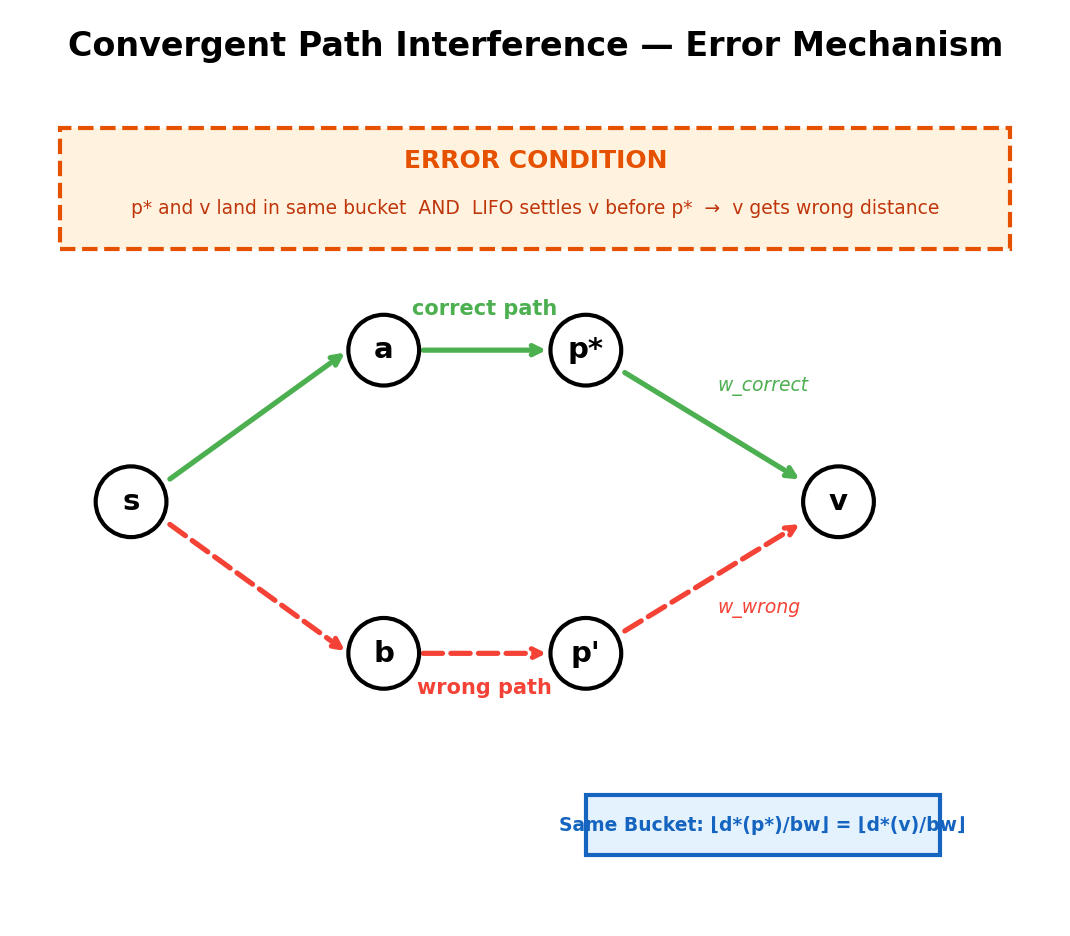

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Convergent Path Interference — Error Mechanism',
             fontsize=16, fontweight='bold', pad=20)

# Nodes
nodes = {
    'source': (1, 4),
    'a':      (3.5, 5.5),
    'b':      (3.5, 2.5),
    'p_corr': (5.5, 5.5),
    'p_wrong':(5.5, 2.5),
    'v':      (8, 4),
}

for name, (nx, ny) in nodes.items():
    circle = plt.Circle((nx, ny), 0.35, facecolor='white', edgecolor='black', linewidth=2, zorder=5)
    ax.add_patch(circle)
    display = {'source': 's', 'a': 'a', 'b': 'b', 'p_corr': 'p*', 'p_wrong': "p'", 'v': 'v'}
    ax.text(nx, ny, display[name], ha='center', va='center', fontsize=14, fontweight='bold', zorder=6)

# Edges — correct path (green)
ax.annotate('', xy=(3.15, 5.5), xytext=(1.35, 4.2),
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
ax.annotate('', xy=(5.15, 5.5), xytext=(3.85, 5.5),
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
ax.annotate('', xy=(7.65, 4.2), xytext=(5.85, 5.3),
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))

# Edges — wrong path (red dashed)
ax.annotate('', xy=(3.15, 2.5), xytext=(1.35, 3.8),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, linestyle='dashed'))
ax.annotate('', xy=(5.15, 2.5), xytext=(3.85, 2.5),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, linestyle='dashed'))
ax.annotate('', xy=(7.65, 3.8), xytext=(5.85, 2.7),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, linestyle='dashed'))

# Edge labels
ax.text(4.5, 5.85, 'correct path', fontsize=10, color='#4CAF50', fontweight='bold', ha='center')
ax.text(4.5, 2.1, 'wrong path', fontsize=10, color='#F44336', fontweight='bold', ha='center')
ax.text(6.8, 5.1, 'w_correct', fontsize=9, color='#4CAF50', style='italic')
ax.text(6.8, 2.9, 'w_wrong', fontsize=9, color='#F44336', style='italic')

# Bucket diagram
ax.add_patch(plt.Rectangle((5.5, 0.5), 3.5, 0.6,
                            facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2))
ax.text(7.25, 0.8, 'Same Bucket: ⌊d*(p*)/bw⌋ = ⌊d*(v)/bw⌋',
        ha='center', va='center', fontsize=9, fontweight='bold', color='#1565C0')

# Condition box
ax.add_patch(plt.Rectangle((0.3, 6.5), 9.4, 1.2, facecolor='#FFF3E0',
                            edgecolor='#E65100', linewidth=2, linestyle='--'))
ax.text(5, 7.3, 'ERROR CONDITION', fontsize=12, fontweight='bold',
        ha='center', color='#E65100')
ax.text(5, 6.85, 'p* and v land in same bucket  AND  LIFO settles v before p*  →  v gets wrong distance',
        fontsize=9, ha='center', color='#BF360C')

plt.show()

---
## Figure 14 — `fig14_error_heatmap.png`
2D heatmap: graphs (rows) × k values (columns), colored by P_src.

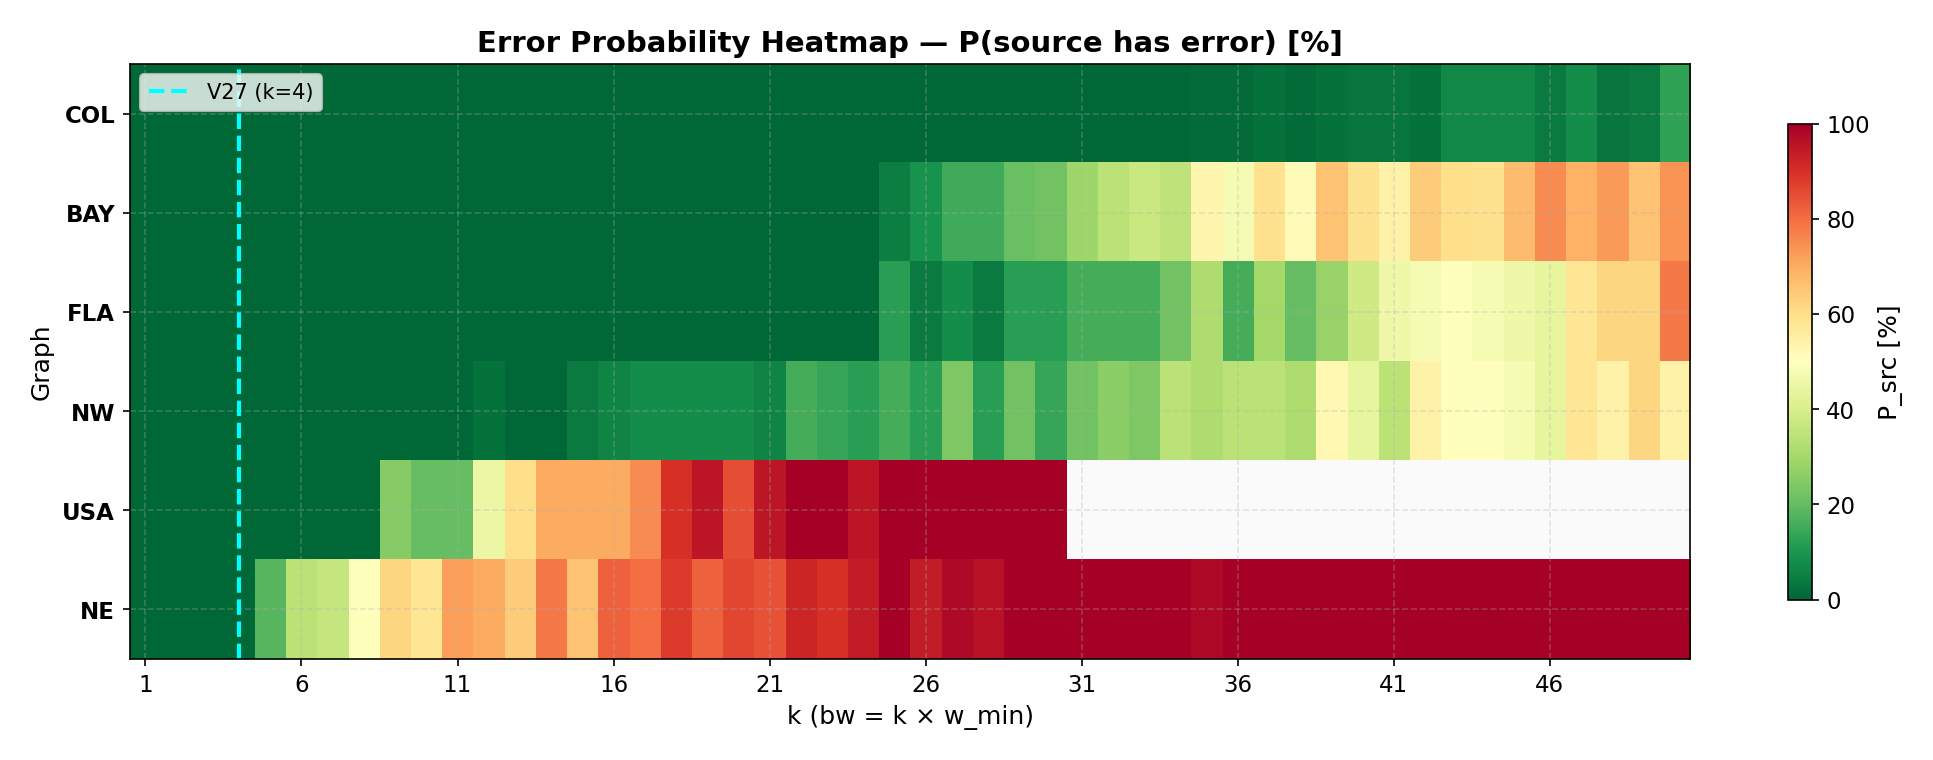

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

graphs_order = ['COL', 'BAY', 'FLA', 'NW', 'USA', 'NE']
all_psrc = {
    'BAY': BAY_psrc[:50],
    'COL': COL_psrc[:50],
    'FLA': FLA_psrc[:50],
    'NW':  NW_psrc[:50],
    'NE':  NE_psrc[:50],
    'USA': USA_psrc[:30] + [None]*20,
}

matrix = []
for g in graphs_order:
    row = []
    for i in range(50):
        val = all_psrc[g][i] if i < len(all_psrc[g]) and all_psrc[g][i] is not None else np.nan
        row.append(val * 100 if not np.isnan(val) else np.nan)
    matrix.append(row)

matrix = np.array(matrix)

im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100,
               interpolation='nearest')
ax.set_xlabel('k (bw = k × w_min)')
ax.set_ylabel('Graph')
ax.set_title('Error Probability Heatmap — P(source has error) [%]',
             fontsize=14, fontweight='bold')
ax.set_yticks(range(len(graphs_order)))
ax.set_yticklabels(graphs_order, fontsize=11, fontweight='bold')
ax.set_xticks(range(0, 50, 5))
ax.set_xticklabels(range(1, 51, 5))

ax.axvline(x=3, color='cyan', linestyle='--', linewidth=2, label='V27 (k=4)')
ax.legend(loc='upper left', fontsize=10)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, label='P_src [%]')

plt.tight_layout()
plt.show()

---
## Figure 15 — `fig15_research_timeline.png`
Visual summary of all 12 research phases with key discoveries.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


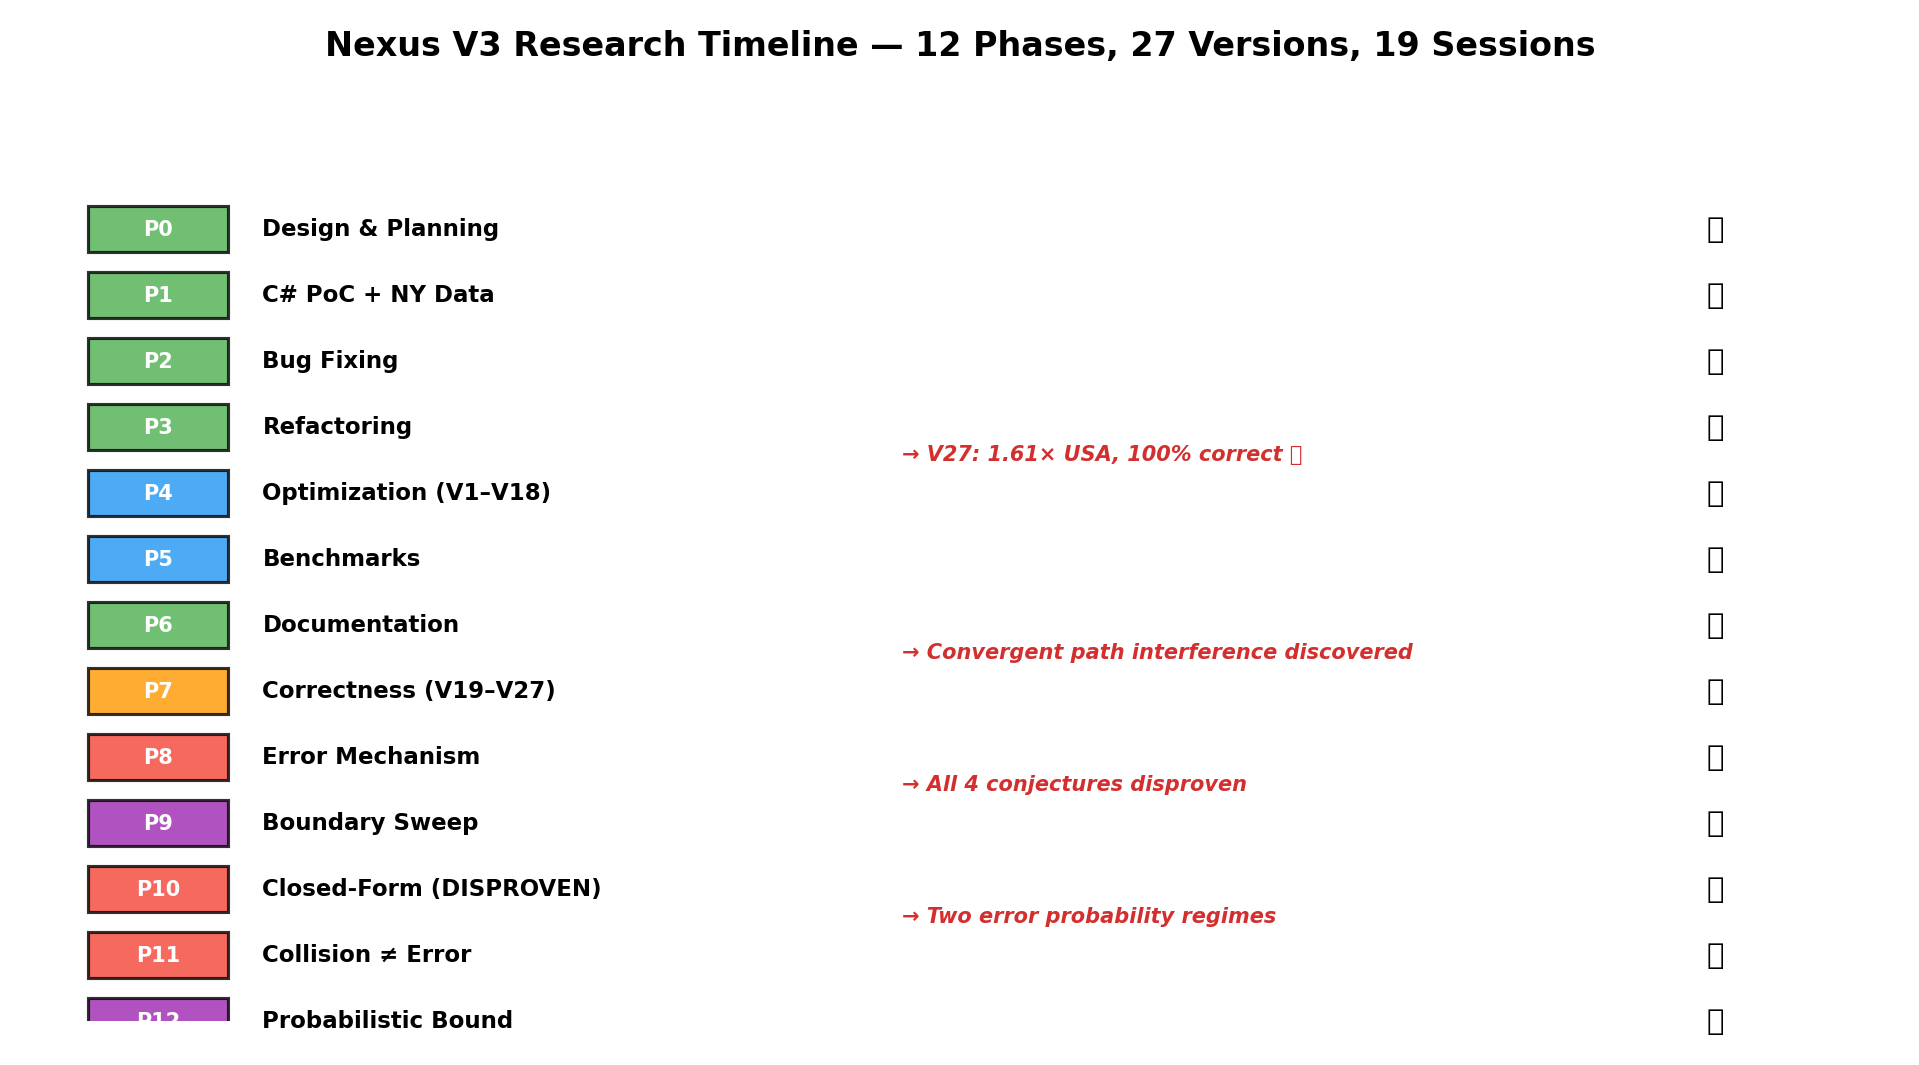

In [18]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')
ax.set_xlim(0, 16)
ax.set_ylim(0, 14)
ax.set_title('Nexus V3 Research Timeline — 12 Phases, 27 Versions, 19 Sessions',
             fontsize=16, fontweight='bold', pad=20)

phases = [
    (0, 'Design & Planning', '✅', '#4CAF50'),
    (1, 'C# PoC + NY Data', '✅', '#4CAF50'),
    (2, 'Bug Fixing', '✅', '#4CAF50'),
    (3, 'Refactoring', '✅', '#4CAF50'),
    (4, 'Optimization (V1–V18)', '✅', '#2196F3'),
    (5, 'Benchmarks', '✅', '#2196F3'),
    (6, 'Documentation', '✅', '#4CAF50'),
    (7, 'Correctness (V19–V27)', '✅', '#FF9800'),
    (8, 'Error Mechanism', '✅', '#F44336'),
    (9, 'Boundary Sweep', '✅', '#9C27B0'),
    (10, 'Closed-Form (DISPROVEN)', '✅', '#F44336'),
    (11, 'Collision ≠ Error', '✅', '#F44336'),
    (12, 'Probabilistic Bound', '✅', '#9C27B0'),
]

for i, (phase_num, name, status, color) in enumerate(phases):
    row = 12 - i
    ax.add_patch(plt.Rectangle((0.5, row - 0.35), 1.2, 0.7,
                 facecolor=color, edgecolor='black', alpha=0.8, linewidth=1.5))
    ax.text(1.1, row, f'P{phase_num}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(2.0, row, f'{name}', ha='left', va='center', fontsize=11, fontweight='bold')
    ax.text(14.5, row, status, ha='center', va='center', fontsize=14)

# Key discoveries
discoveries = [
    (7.5, 8.5, 'V27: 1.61× USA, 100% correct 🏆'),
    (7.5, 5.5, 'Convergent path interference discovered'),
    (7.5, 3.5, 'All 4 conjectures disproven'),
    (7.5, 1.5, 'Two error probability regimes'),
]
for dx, dy, text in discoveries:
    ax.text(dx, dy, f'→ {text}', fontsize=10, color='#D32F2F',
            fontweight='bold', style='italic')

plt.show()

---
## 📥 Save All Figures to Files

Run the cell below to save all 15 figures as PNG files in the current directory.
Alternatively, right-click each figure above → *Save image as...* with the filename shown.

In [19]:
import os

def save_all_figures():
    """Re-generate and save all 15 figures as PNG files."""

    print('Saving all 15 figures...\n')

    # ── Fig 1 ──
    fig, ax = plt.subplots(figsize=(12, 7))
    for name, k, psrc in [('NE',NE_k,NE_psrc),('USA',USA_k,USA_psrc),('NW',NW_k,NW_psrc),('BAY',BAY_k,BAY_psrc),('FLA',FLA_k,FLA_psrc),('COL',COL_k,COL_psrc)]:
        ax.plot(k, [p*100 for p in psrc], color=COLORS[name], marker=MARKERS[name], markersize=4, linewidth=2, label=name, markevery=3)
    ax.axvline(x=4, color='green', linestyle=':', linewidth=2, alpha=0.7, label='V27 (k=4)')
    ax.set_xlabel('k  (bucket width = k × w_min)'); ax.set_ylabel('P(source has ≥1 error)  [%]')
    ax.set_title('Error Probability vs Bucket Width Multiplier — All 6 DIMACS Graphs')
    ax.set_xlim(0, 62); ax.set_ylim(-2, 105); ax.legend(loc='center right', framealpha=0.9)
    ax.annotate('STEEP SIGMOID\n(NE, USA)', xy=(15, 85), fontsize=11, color='#F44336', fontweight='bold', ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#F44336'))
    ax.annotate('GRADUAL RISE\n(BAY, COL, FLA, NW)', xy=(48, 30), fontsize=11, color='#4CAF50', fontweight='bold', ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#4CAF50'))
    fig.savefig('fig01_error_probability_overlay.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig01_error_probability_overlay.png')

    # ── Fig 2 ──
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Error Probability Curves — Individual DIMACS Graphs', fontsize=16, fontweight='bold')
    for idx, (name, k, psrc, info) in enumerate([('BAY',BAY_k,BAY_psrc,'321K nodes, w_min=2\n100 sources'),('COL',COL_k,COL_psrc,'436K nodes, w_min=2\n100 sources'),('FLA',FLA_k,FLA_psrc,'1.07M nodes, w_min=1\n50 sources'),('NW',NW_k,NW_psrc,'1.21M nodes, w_min=2\n50 sources'),('NE',NE_k,NE_psrc,'1.52M nodes, w_min=2\n50 sources'),('USA',USA_k,USA_psrc,'23.9M nodes, w_min=1\n20 sources')]):
        ax = axes[idx//3][idx%3]; pct = [p*100 for p in psrc]
        ax.fill_between(k, pct, alpha=0.2, color=COLORS[name])
        ax.plot(k, pct, color=COLORS[name], linewidth=2.5, marker=MARKERS[name], markersize=3, markevery=5)
        ax.axvline(x=4, color='green', linestyle=':', linewidth=1.5, alpha=0.6)
        first_err_k = next((ki for ki, p in zip(k, psrc) if p > 0), None)
        if first_err_k:
            first_err_p = psrc[k.index(first_err_k)] * 100
            ax.annotate(f'1st error\nk={first_err_k}', xy=(first_err_k, first_err_p), xytext=(first_err_k+5, first_err_p+15), arrowprops=dict(arrowstyle='->', color='red', lw=1.5), fontsize=9, color='red', fontweight='bold')
        ax.set_title(f'{name}', fontsize=13, fontweight='bold', color=COLORS[name])
        ax.set_xlabel('k (bw = k × w_min)'); ax.set_ylabel('P_src [%]'); ax.set_ylim(-2, 105)
        ax.text(0.98, 0.02, info, transform=ax.transAxes, fontsize=8, ha='right', va='bottom', style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    fig.tight_layout(); fig.savefig('fig02_error_probability_subplots.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig02_error_probability_subplots.png')

    # ── Fig 3 ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('NE Graph: Phase Transition — Error Avalanche at k=17', fontsize=15, fontweight='bold')
    ax1.semilogy(NE_k, [max(e, 0.5) for e in NE_maxerr], color='#F44336', linewidth=2.5, marker='v', markersize=4, markevery=3)
    ax1.axvline(x=17, color='orange', linestyle='--', linewidth=2, label='k=17 (phase transition)'); ax1.set_xlabel('k (bw = k × w_min)'); ax1.set_ylabel('Max errors per source (log scale)'); ax1.set_title('Max Error Count per Source'); ax1.legend()
    ax1.annotate('2 → 2,270\n(1,135× jump!)', xy=(17, 2270), xytext=(25, 200), arrowprops=dict(arrowstyle='->', color='orange', lw=2), fontsize=11, fontweight='bold', color='orange', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='orange'))
    ax1.annotate('88,129', xy=(44, 88129), xytext=(35, 88129), fontsize=9, fontweight='bold', color='red')
    ax2.semilogy(NE_k, [max(e, 0.5) for e in NE_totalerr], color='#D32F2F', linewidth=2.5, marker='v', markersize=4, markevery=3)
    ax2.axvline(x=17, color='orange', linestyle='--', linewidth=2, label='k=17 (phase transition)'); ax2.set_xlabel('k (bw = k × w_min)'); ax2.set_ylabel('Total errors across 50 sources (log scale)'); ax2.set_title('Total Error Count (50 sources)'); ax2.legend()
    ax2.annotate('43 → 2,310\n(54× jump)', xy=(17, 2310), xytext=(25, 500), arrowprops=dict(arrowstyle='->', color='orange', lw=2), fontsize=11, fontweight='bold', color='orange', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='orange'))
    fig.tight_layout(); fig.savefig('fig03_ne_phase_transition.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig03_ne_phase_transition.png')

    # ── Fig 4 ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Correctness Boundary: Safe Bucket Width Across DIMACS Graphs', fontsize=15, fontweight='bold')
    graphs = ['BAY','COL','FLA','NW','NE','USA']; x = np.arange(len(graphs)); width = 0.35
    sbw = [boundary_data[g][3] for g in graphs]; fbw = [boundary_data[g][4] for g in graphs]; sk = [boundary_data[g][5] for g in graphs]
    b1 = ax1.bar(x-width/2, sbw, width, label='Safe bw', color=[COLORS[g] for g in graphs], alpha=0.8, edgecolor='black')
    ax1.bar(x+width/2, fbw, width, label='Fail bw', color=[COLORS[g] for g in graphs], alpha=0.4, edgecolor='black', hatch='//')
    ax1.set_xlabel('Graph'); ax1.set_ylabel('Bucket Width'); ax1.set_title('Safe vs Fail Bucket Width'); ax1.set_xticks(x); ax1.set_xticklabels(graphs); ax1.legend()
    for bar in b1: ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1, f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    b3 = ax2.bar(x, sk, 0.6, color=[COLORS[g] for g in graphs], edgecolor='black', alpha=0.8)
    ax2.axhline(y=4, color='green', linestyle='--', linewidth=2, label='V27 (k=4)'); ax2.set_xlabel('Graph'); ax2.set_ylabel('Safe k (multiples of w_min)'); ax2.set_title('Safe Boundary as Multiples of w_min'); ax2.set_xticks(x); ax2.set_xticklabels(graphs); ax2.legend()
    for bar, g in zip(b3, graphs): ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3, f'k={int(bar.get_height())}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    fig.tight_layout(); fig.savefig('fig04_boundary_sweep.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig04_boundary_sweep.png')

    # ── Fig 5 ──
    fig, ax = plt.subplots(figsize=(12, 7))
    graphs = ['BAY','COL','FLA','NW','NE','USA']; x = np.arange(len(graphs)); width = 0.2
    actual = [conjecture_data[g][0] for g in graphs]; pc = [conjecture_data[g][1] for g in graphs]; pw = [conjecture_data[g][2] for g in graphs]; pg = [conjecture_data[g][3] for g in graphs]
    ax.bar(x-1.5*width, actual, width, label='Actual safe_bw', color='#2196F3', edgecolor='black', linewidth=1.2)
    ax.bar(x-0.5*width, pc, width, label='Conj 1: minCritBw−1', color='#F44336', edgecolor='black', alpha=0.7, hatch='//')
    ax.bar(x+0.5*width, pw, width, label='Conj 2: min(w_correct)', color='#FF9800', edgecolor='black', alpha=0.7, hatch='\\\\')
    ax.bar(x+1.5*width, pg, width, label='Conj 3: min(gap)', color='#9C27B0', edgecolor='black', alpha=0.7, hatch='xx')
    ax.set_xlabel('Graph'); ax.set_ylabel('Predicted / Actual safe_bw'); ax.set_title('All 4 Conjectures DISPROVEN — Predicted vs Actual Safe Bucket Width'); ax.set_xticks(x); ax.set_xticklabels(graphs); ax.legend(loc='upper left')
    for i, g in enumerate(graphs): ax.annotate(f'{actual[i]}', xy=(i-1.5*width, actual[i]), xytext=(i-1.5*width, actual[i]+2), ha='center', fontsize=8, fontweight='bold', color='#1565C0')
    ax.text(0.98, 0.95, 'ALL CONJECTURES ❌\nPredictions: 1–2\nActual: 8–54', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='right', color='#D32F2F', bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFEBEE', edgecolor='#D32F2F'))
    fig.savefig('fig05_conjecture_scorecard.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig05_conjecture_scorecard.png')

    # ── Fig 6 ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Collision ≠ Error — Same-Bucket Collisions vs Actual Errors', fontsize=15, fontweight='bold')
    graphs = ['BAY','NE','NW','COL']; x = np.arange(len(graphs)); width = 0.35
    cf = [collision_data[g][2] for g in graphs]; ef = [collision_data[g][3] for g in graphs]
    b1 = ax1.bar(x-width/2, cf, width, label='Collisions', color='#2196F3', edgecolor='black')
    b2 = ax1.bar(x+width/2, ef, width, label='Errors', color='#F44336', edgecolor='black')
    ax1.set_xlabel('Graph'); ax1.set_ylabel('Count'); ax1.set_title('At Fail Bucket Width'); ax1.set_xticks(x); ax1.set_xticklabels(graphs); ax1.legend()
    for bar in b1: ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+100, f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
    for bar in b2: ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+100, f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8, color='red')
    er = [(collision_data[g][3]/collision_data[g][2]*100) if collision_data[g][2]>0 else 0 for g in graphs]
    cr = ['#F44336' if r>0 else '#4CAF50' for r in er]
    b3 = ax2.bar(x, er, 0.6, color=cr, edgecolor='black')
    ax2.set_xlabel('Graph'); ax2.set_ylabel('Error Rate  [% of collisions]'); ax2.set_title('Error / Collision Rate at Fail bw'); ax2.set_xticks(x); ax2.set_xticklabels(graphs)
    for bar, rate in zip(b3, er): ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.05, f'{rate:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2.annotate('0 errors from\n11,171 collisions!', xy=(3, 0), xytext=(2.2, 2.0), arrowprops=dict(arrowstyle='->', color='green', lw=2), fontsize=10, fontweight='bold', color='green')
    fig.tight_layout(); fig.savefig('fig06_collision_vs_error.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig06_collision_vs_error.png')

    # ── Fig 7 ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Worst-Case Family 1: Simple Diamond — safe_bw vs w_correct', fontsize=15, fontweight='bold')
    ax1.plot(family1_W, family1_safe, 'o-', color='#2196F3', linewidth=2, markersize=6, label='Actual safe_bw')
    ax1.plot(family1_W, family1_W, '--', color='gray', alpha=0.5, label='y = W (Dinitz)')
    ax1.plot(family1_W, [w*2 for w in family1_W], '--', color='orange', alpha=0.5, label='y = 2W')
    ax1.set_xlabel('W (correct edge weight)'); ax1.set_ylabel('Safe bucket width'); ax1.set_title('safe_bw vs w_correct'); ax1.legend()
    ax2.plot(family1_W, family1_ratio, 's-', color='#F44336', linewidth=2, markersize=6)
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Ratio = 1 (Dinitz)'); ax2.set_xlabel('W (correct edge weight)'); ax2.set_ylabel('safe_bw / W ratio'); ax2.set_title('Ratio is NOT Constant (1.5× to 75×)'); ax2.legend()
    ax2.annotate('75×', xy=(50, 75/50), xytext=(42, 2.0), arrowprops=dict(arrowstyle='->', color='red', lw=1.5), fontsize=11, fontweight='bold', color='red')
    fig.tight_layout(); fig.savefig('fig07_family1_ratio.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig07_family1_ratio.png')

    # ── Fig 8 ──
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['#4CAF50' if e == 0 else '#F44336' for e in family3_errors]
    ax.bar(family3_bw, family3_errors, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Bucket Width (bw)'); ax.set_ylabel('Error Count')
    ax.set_title('Non-Monotonic Errors — Family 3 (5 Diamonds, w_correct=[5,10,20,30,50])\nErrors appear, disappear, and reappear as bw increases!', fontsize=13, fontweight='bold')
    for bw_val in [13,17,26,34,52]: ax.annotate('0!', xy=(bw_val, 0), xytext=(bw_val, 5), ha='center', fontsize=8, fontweight='bold', color='green', arrowprops=dict(arrowstyle='->', color='green', lw=1))
    ax.legend(handles=[Patch(facecolor='#4CAF50', edgecolor='black', label='0 errors (safe)'), Patch(facecolor='#F44336', edgecolor='black', label='>0 errors (broken)')], loc='upper right')
    fig.savefig('fig08_family3_nonmonotonic.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig08_family3_nonmonotonic.png')

    # ── Fig 9 ──
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(family5_gap, family5_safe, 'o-', color='#9C27B0', linewidth=2, markersize=5)
    ax.fill_between(family5_gap, family5_safe, alpha=0.15, color='#9C27B0')
    ax.set_xlabel('Gap (error magnitude = d_wrong(v) − d*(v))'); ax.set_ylabel('Safe bucket width')
    ax.set_title('Family 5: Larger Gap → Larger Safe Boundary (Staircase Pattern)\nW=10, P=110', fontsize=13, fontweight='bold')
    ax.annotate('Jump: 54 → 82', xy=(45, 82), xytext=(35, 85), arrowprops=dict(arrowstyle='->', color='purple', lw=1.5), fontsize=10, fontweight='bold', color='purple')
    fig.savefig('fig09_family5_gap.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig09_family5_gap.png')

    # ── Fig 10 ──
    fig, ax = plt.subplots(figsize=(10, 6))
    dp = list(v27_perf.keys()); x = np.arange(len(dp)); width = 0.35
    b1 = ax.bar(x-width/2, [v27_perf[d][0] for d in dp], width, label='V18 (broken on USA)', color='#FF9800', edgecolor='black', alpha=0.8)
    b2 = ax.bar(x+width/2, [v27_perf[d][1] for d in dp], width, label='V27 (100% correct)', color='#2196F3', edgecolor='black', alpha=0.8)
    ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Baseline (Dijkstra)')
    ax.set_xlabel('Dataset'); ax.set_ylabel('Speedup vs DijkstraReusable2'); ax.set_title('V27 vs V18: Correctness Costs ~20% Speed', fontsize=14, fontweight='bold'); ax.set_xticks(x); ax.set_xticklabels(dp); ax.legend()
    for i, (bar, c) in enumerate(zip(b1, [v27_perf[d][2] for d in dp])): ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.2, f'{bar.get_height():.2f}×\n{"✅" if c else "❌"}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in b2: ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.2, f'{bar.get_height():.2f}×\n✅', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1565C0')
    fig.savefig('fig10_v27_performance.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig10_v27_performance.png')

    # ── Fig 11 ──
    fig, ax = plt.subplots(figsize=(16, 7))
    versions = ['V1','V2','V6','V9','V12','V16','V18','V19','V22','V24','V27']
    sp = [1.0,1.05,1.13,2.2,2.5,2.4,2.52,1.21,1.27,1.43,1.61]; co = [True,True,True,True,True,True,False,True,True,True,True]
    lb = ['Baseline','Bitmap scan','+13% bitmap','First-live\nextraction','AoS layout','Reusable PQ','Hybrid reset\n(USA ❌)','Adaptive 1M\nbuckets','Fixed 64K\nbw=minW','16K buckets\nbw=minW','16K buckets\nbw=4×minW\n🏆']
    cv = ['#4CAF50' if c else '#F44336' for c in co]; x = np.arange(len(versions))
    bars = ax.bar(x, sp, color=cv, edgecolor='black', alpha=0.85, width=0.7)
    ax.set_xlabel('Version'); ax.set_ylabel('Speedup vs Dijkstra'); ax.set_title('The 27-Version Journey: From V1 to V27 (Correct Champion)', fontsize=14, fontweight='bold'); ax.set_xticks(x); ax.set_xticklabels(versions, fontsize=10)
    for i, (bar, label) in enumerate(zip(bars, lb)): ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.05, label, ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvspan(-0.5, 5.5, alpha=0.05, color='blue'); ax.axvspan(5.5, 6.5, alpha=0.08, color='red'); ax.axvspan(6.5, 10.5, alpha=0.05, color='green')
    ax.text(2.5, 2.8, 'Phase 4: Optimization\n(V1–V18)', ha='center', fontsize=10, style='italic', color='blue')
    ax.text(8.5, 2.8, 'Phase 7: Correctness Quest\n(V19–V27)', ha='center', fontsize=10, style='italic', color='green')
    ax.legend(handles=[Patch(facecolor='#4CAF50', edgecolor='black', label='Correct'), Patch(facecolor='#F44336', edgecolor='black', label='Incorrect')], loc='upper left')
    fig.savefig('fig11_version_evolution.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig11_version_evolution.png')

    # ── Fig 12 ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Two Distinct Error Probability Regimes', fontsize=16, fontweight='bold')
    ax1.plot(NE_k, [p*100 for p in NE_psrc], color=COLORS['NE'], linewidth=2.5, marker='v', markersize=4, markevery=3, label='NE (w_min=2)')
    ax1.plot(USA_k, [p*100 for p in USA_psrc], color=COLORS['USA'], linewidth=2.5, marker='P', markersize=5, markevery=2, label='USA (w_min=1)')
    ax1.fill_between(NE_k, [p*100 for p in NE_psrc], alpha=0.1, color=COLORS['NE']); ax1.fill_between(USA_k, [p*100 for p in USA_psrc], alpha=0.1, color=COLORS['USA'])
    ax1.axvline(x=4, color='green', linestyle=':', linewidth=2, alpha=0.7, label='V27 (k=4)'); ax1.set_xlabel('k (bw = k × w_min)'); ax1.set_ylabel('P(source has ≥1 error) [%]'); ax1.set_title('🔴 Steep Sigmoid Regime', fontsize=13, color='#D32F2F'); ax1.set_ylim(-2, 105); ax1.legend(loc='center right')
    ax1.text(0.5, 0.15, 'Errors appear early\nReach 100% quickly\nError avalanche possible', transform=ax1.transAxes, fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.8))
    ax2.plot(BAY_k, [p*100 for p in BAY_psrc], color=COLORS['BAY'], linewidth=2.5, marker='o', markersize=4, markevery=4, label='BAY')
    ax2.plot(COL_k, [p*100 for p in COL_psrc], color=COLORS['COL'], linewidth=2.5, marker='s', markersize=4, markevery=4, label='COL')
    ax2.plot(FLA_k, [p*100 for p in FLA_psrc], color=COLORS['FLA'], linewidth=2.5, marker='^', markersize=4, markevery=3, label='FLA')
    ax2.plot(NW_k, [p*100 for p in NW_psrc], color=COLORS['NW'], linewidth=2.5, marker='D', markersize=4, markevery=3, label='NW')
    ax2.axvline(x=4, color='green', linestyle=':', linewidth=2, alpha=0.7, label='V27 (k=4)'); ax2.set_xlabel('k (bw = k × w_min)'); ax2.set_ylabel('P(source has ≥1 error) [%]'); ax2.set_title('🟢 Gradual Rise Regime', fontsize=13, color='#388E3C'); ax2.set_ylim(-2, 105); ax2.legend(loc='center right')
    ax2.text(0.5, 0.85, 'Errors appear late\nNever reach 100%\nFew errors per source', transform=ax2.transAxes, fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))
    fig.tight_layout(); fig.savefig('fig12_two_regimes.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig12_two_regimes.png')

    # ── Fig 13 ──
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title('Convergent Path Interference — Error Mechanism', fontsize=16, fontweight='bold', pad=20)
    nodes = {'source':(1,4),'a':(3.5,5.5),'b':(3.5,2.5),'p_corr':(5.5,5.5),'p_wrong':(5.5,2.5),'v':(8,4)}
    disp = {'source':'s','a':'a','b':'b','p_corr':'p*','p_wrong':"p'",'v':'v'}
    for name, (nx, ny) in nodes.items():
        ax.add_patch(plt.Circle((nx, ny), 0.35, facecolor='white', edgecolor='black', linewidth=2, zorder=5))
        ax.text(nx, ny, disp[name], ha='center', va='center', fontsize=14, fontweight='bold', zorder=6)
    ax.annotate('', xy=(3.15,5.5), xytext=(1.35,4.2), arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
    ax.annotate('', xy=(5.15,5.5), xytext=(3.85,5.5), arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
    ax.annotate('', xy=(7.65,4.2), xytext=(5.85,5.3), arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
    ax.annotate('', xy=(3.15,2.5), xytext=(1.35,3.8), arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, linestyle='dashed'))
    ax.annotate('', xy=(5.15,2.5), xytext=(3.85,2.5), arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, linestyle='dashed'))
    ax.annotate('', xy=(7.65,3.8), xytext=(5.85,2.7), arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, linestyle='dashed'))
    ax.text(4.5, 5.85, 'correct path', fontsize=10, color='#4CAF50', fontweight='bold', ha='center')
    ax.text(4.5, 2.1, 'wrong path', fontsize=10, color='#F44336', fontweight='bold', ha='center')
    ax.text(6.8, 5.1, 'w_correct', fontsize=9, color='#4CAF50', style='italic')
    ax.text(6.8, 2.9, 'w_wrong', fontsize=9, color='#F44336', style='italic')
    ax.add_patch(plt.Rectangle((5.5, 0.5), 3.5, 0.6, facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2))
    ax.text(7.25, 0.8, 'Same Bucket: ⌊d*(p*)/bw⌋ = ⌊d*(v)/bw⌋', ha='center', va='center', fontsize=9, fontweight='bold', color='#1565C0')
    ax.add_patch(plt.Rectangle((0.3, 6.5), 9.4, 1.2, facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2, linestyle='--'))
    ax.text(5, 7.3, 'ERROR CONDITION', fontsize=12, fontweight='bold', ha='center', color='#E65100')
    ax.text(5, 6.85, 'p* and v land in same bucket  AND  LIFO settles v before p*  →  v gets wrong distance', fontsize=9, ha='center', color='#BF360C')
    fig.savefig('fig13_convergent_path_diagram.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig13_convergent_path_diagram.png')

    # ── Fig 14 ──
    fig, ax = plt.subplots(figsize=(14, 5))
    go = ['COL','BAY','FLA','NW','USA','NE']
    ap = {'BAY':BAY_psrc[:50],'COL':COL_psrc[:50],'FLA':FLA_psrc[:50],'NW':NW_psrc[:50],'NE':NE_psrc[:50],'USA':USA_psrc[:30]+[None]*20}
    matrix = []
    for g in go:
        row = []
        for i in range(50):
            val = ap[g][i] if i < len(ap[g]) and ap[g][i] is not None else np.nan
            row.append(val*100 if not np.isnan(val) else np.nan)
        matrix.append(row)
    matrix = np.array(matrix)
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100, interpolation='nearest')
    ax.set_xlabel('k (bw = k × w_min)'); ax.set_ylabel('Graph'); ax.set_title('Error Probability Heatmap — P(source has error) [%]', fontsize=14, fontweight='bold')
    ax.set_yticks(range(len(go))); ax.set_yticklabels(go, fontsize=11, fontweight='bold'); ax.set_xticks(range(0,50,5)); ax.set_xticklabels(range(1,51,5))
    ax.axvline(x=3, color='cyan', linestyle='--', linewidth=2, label='V27 (k=4)'); ax.legend(loc='upper left', fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8, label='P_src [%]')
    fig.savefig('fig14_error_heatmap.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig14_error_heatmap.png')

    # ── Fig 15 ──
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('off'); ax.set_xlim(0, 16); ax.set_ylim(0, 14)
    ax.set_title('Nexus V3 Research Timeline — 12 Phases, 27 Versions, 19 Sessions', fontsize=16, fontweight='bold', pad=20)
    phases = [(0,'Design & Planning','✅','#4CAF50'),(1,'C# PoC + NY Data','✅','#4CAF50'),(2,'Bug Fixing','✅','#4CAF50'),(3,'Refactoring','✅','#4CAF50'),(4,'Optimization (V1–V18)','✅','#2196F3'),(5,'Benchmarks','✅','#2196F3'),(6,'Documentation','✅','#4CAF50'),(7,'Correctness (V19–V27)','✅','#FF9800'),(8,'Error Mechanism','✅','#F44336'),(9,'Boundary Sweep','✅','#9C27B0'),(10,'Closed-Form (DISPROVEN)','✅','#F44336'),(11,'Collision ≠ Error','✅','#F44336'),(12,'Probabilistic Bound','✅','#9C27B0')]
    for i, (pn, name, status, color) in enumerate(phases):
        row = 12 - i
        ax.add_patch(plt.Rectangle((0.5, row-0.35), 1.2, 0.7, facecolor=color, edgecolor='black', alpha=0.8, linewidth=1.5))
        ax.text(1.1, row, f'P{pn}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        ax.text(2.0, row, f'{name}', ha='left', va='center', fontsize=11, fontweight='bold')
        ax.text(14.5, row, status, ha='center', va='center', fontsize=14)
    for dx, dy, text in [(7.5,8.5,'V27: 1.61× USA, 100% correct 🏆'),(7.5,5.5,'Convergent path interference discovered'),(7.5,3.5,'All 4 conjectures disproven'),(7.5,1.5,'Two error probability regimes')]:
        ax.text(dx, dy, f'→ {text}', fontsize=10, color='#D32F2F', fontweight='bold', style='italic')
    fig.savefig('fig15_research_timeline.png', dpi=150, bbox_inches='tight'); plt.close(fig)
    print('  ✅ fig15_research_timeline.png')

    print('\n═══════════════════════════════════════════════════════════════')
    print('  ✅ All 15 figures saved to current directory!')
    print('═══════════════════════════════════════════════════════════════')

save_all_figures()

Saving all 15 figures...

  ✅ fig01_error_probability_overlay.png
  ✅ fig02_error_probability_subplots.png
  ✅ fig03_ne_phase_transition.png
  ✅ fig04_boundary_sweep.png


/tmp/ipykernel_763/2772653569.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.savefig('fig05_conjecture_scorecard.png', dpi=150, bbox_inches='tight'); plt.close(fig)


  ✅ fig05_conjecture_scorecard.png
  ✅ fig06_collision_vs_error.png
  ✅ fig07_family1_ratio.png
  ✅ fig08_family3_nonmonotonic.png
  ✅ fig09_family5_gap.png


/tmp/ipykernel_763/2772653569.py:143: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig('fig10_v27_performance.png', dpi=150, bbox_inches='tight'); plt.close(fig)
/tmp/ipykernel_763/2772653569.py:143: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.savefig('fig10_v27_performance.png', dpi=150, bbox_inches='tight'); plt.close(fig)


  ✅ fig10_v27_performance.png


...

  ✅ fig11_version_evolution.png


/tmp/ipykernel_763/2772653569.py:177: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('fig12_two_regimes.png', dpi=150, bbox_inches='tight'); plt.close(fig)
/tmp/ipykernel_763/2772653569.py:177: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('fig12_two_regimes.png', dpi=150, bbox_inches='tight'); plt.close(fig)


  ✅ fig12_two_regimes.png
  ✅ fig13_convergent_path_diagram.png
  ✅ fig14_error_heatmap.png


/tmp/ipykernel_763/2772653569.py:240: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig('fig15_research_timeline.png', dpi=150, bbox_inches='tight'); plt.close(fig)
/tmp/ipykernel_763/2772653569.py:240: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.savefig('fig15_research_timeline.png', dpi=150, bbox_inches='tight'); plt.close(fig)


  ✅ fig15_research_timeline.png

═══════════════════════════════════════════════════════════════
  ✅ All 15 figures saved to current directory!
═══════════════════════════════════════════════════════════════


---
## 📋 Figure → Filename Mapping

Copy each generated image and save with these names:

| Cell # | Save As | Description |
|--------|---------|-------------|
| 1 | `fig01_error_probability_overlay.png` | All 6 graphs P_src vs k |
| 2 | `fig02_error_probability_subplots.png` | 2×3 grid individual curves |
| 3 | `fig03_ne_phase_transition.png` | NE error avalanche at k=17 |
| 4 | `fig04_boundary_sweep.png` | Safe/Fail bw bars |
| 5 | `fig05_conjecture_scorecard.png` | 4 conjectures vs actual |
| 6 | `fig06_collision_vs_error.png` | Collision ≠ Error |
| 7 | `fig07_family1_ratio.png` | safe_bw/W ratio |
| 8 | `fig08_family3_nonmonotonic.png` | Non-monotonic errors |
| 9 | `fig09_family5_gap.png` | Gap vs safe_bw staircase |
| 10 | `fig10_v27_performance.png` | V18 vs V27 speedup |
| 11 | `fig11_version_evolution.png` | 27-version journey |
| 12 | `fig12_two_regimes.png` | Steep vs gradual regimes |
| 13 | `fig13_convergent_path_diagram.png` | Error mechanism diagram |
| 14 | `fig14_error_heatmap.png` | P_src heatmap matrix |
| 15 | `fig15_research_timeline.png` | 12 phases timeline |